#ITF Tournament Participation Decision

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_excel(
    '/content/drive/MyDrive/Licenta/Dataset_licenta.xlsx',
    sheet_name='Dataset_ML'
)

df.head()

,player_id,level,age,budget,pref_surface,train_surface,travel,coach,tournament_id,country,category,surface,period,nights,cost,decision,decision_binary,reason
0,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T1,Turkey,M15,Clay,March,7,850,Yes,1,Location
1,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T2,Spain,M25,Clay,March,7,1300,Yes,1,Tournament level
2,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T3,China,M25,Hard,March,8,2300,No,0,Cost
3,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T4,France,M25,Hard,March,7,900,Yes,1,Tournament level
4,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T5,Greece,M15,Hard,March,7,700,Yes,1,Location


In acest pas am incarcat datasetul utilizat in cadrul lucrarii. Acesta contine date colectate printr un chestionar, fiecare rand reprezentand o decizie a unui jucator de tenis de a participa sau nu la un anumit turneu.

Functia head() e utilizata pentru a vizualiza primele randuri ale datasetului si pentru a intelege structura acestuia.

In [3]:
df.shape

(1056, 18)

Datasetul contine un numar de 1056 de randuri si 18 coloane. Fiecare rand reprezinta o decizie, iar fiecare coloana reprezinta o caracteristica.

In [4]:
df.columns

Index(['player_id', 'level', 'age', 'budget', 'pref_surface', 'train_surface',
       'travel', 'coach', 'tournament_id', 'country', 'category', 'surface',
       'period', 'nights', 'cost', 'decision', 'decision_binary', 'reason'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   player_id        1056 non-null   int64 
 1   level            1056 non-null   object
 2   age              1056 non-null   object
 3   budget           1056 non-null   object
 4   pref_surface     1056 non-null   object
 5   train_surface    1056 non-null   object
 6   travel           1056 non-null   object
 7   coach            1056 non-null   object
 8   tournament_id    1056 non-null   object
 9   country          1056 non-null   object
 10  category         1056 non-null   object
 11  surface          1056 non-null   object
 12  period           1056 non-null   object
 13  nights           1056 non-null   int64 
 14  cost             1056 non-null   int64 
 15  decision         1056 non-null   object
 16  decision_binary  1056 non-null   int64 
 17  reason           1056 non-null   

In [6]:
df.describe()


,player_id,nights,cost,decision_binary
count,1056.000000,1056.000000,1056.000000,1056.000000
mean,44.500000,7.166667,1245.833333,0.620265
std,25.413807,0.553033,628.608383,0.485551
min,1.000000,6.000000,650.000000,0.000000
25%,22.750000,7.000000,850.000000,0.000000
50%,44.500000,7.000000,925.000000,1.000000
75%,66.250000,7.250000,1525.000000,1.000000
max,88.000000,8.000000,2400.000000,1.000000


In [7]:
df.isnull().sum()

,0
player_id,0
level,0
age,0
budget,0
pref_surface,0
train_surface,0
travel,0
coach,0
tournament_id,0
country,0


In acest pas am verificat existenta valorilor lipsa in dataset, acestea fiind excluse. Tratarea valorilor lipsa este importanta deoarece acestea pot afecta performanta modelelor de Machine Learning.

Definim variabila tinta decision_binary, care indica daca un jucator participa (1) sau nu participa (0) la un turneu.


In [8]:
y = df["decision_binary"]

In [9]:
df["decision_binary"].value_counts()

,count
decision_binary,
1,655
0,401


Distributia variabilei tinta arata ca exista 655 de cazuri in care jucatorii aleg sa participe la un turneu si 401 de cazuri in care aleg sa nu participe.

Datasetul nu este perfect echilibrat, insa diferenta nu este foarte mare, ceea ce inseamna ca modelele de clasificare pot fi antrenate in conditii rezonabile fara a fi necesare tehnici speciale de echilibrare a datelor.

Se observa totusi o usoara tendinta catre clasa pozitiva.

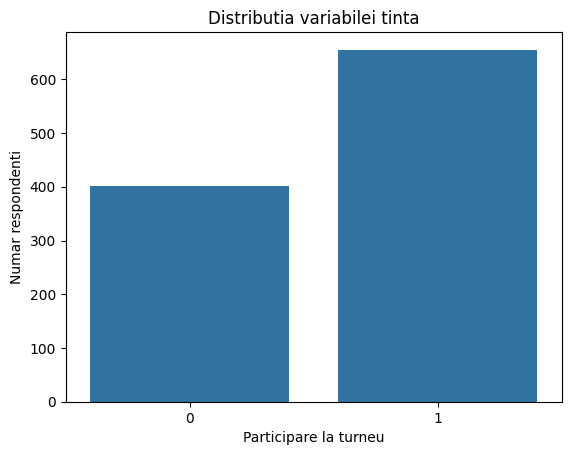

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)

plt.title("Distributia variabilei tinta")
plt.xlabel("Participare la turneu")
plt.ylabel("Numar respondenti")

plt.show()

Pentru o vizualizare mai clara a distributiei variabilei tinta, am reprezentat datele sub forma de grafic de tip bar chart.


#***EDA***

In [11]:
df.head(10)

,player_id,level,age,budget,pref_surface,train_surface,travel,coach,tournament_id,country,category,surface,period,nights,cost,decision,decision_binary,reason
0,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T1,Turkey,M15,Clay,March,7,850,Yes,1,Location
1,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T2,Spain,M25,Clay,March,7,1300,Yes,1,Tournament level
2,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T3,China,M25,Hard,March,8,2300,No,0,Cost
3,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T4,France,M25,Hard,March,7,900,Yes,1,Tournament level
4,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T5,Greece,M15,Hard,March,7,700,Yes,1,Location
5,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T6,Australia,M25,Hard,February,8,2400,No,0,Location
6,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T7,Romania,M15,Hard,February,7,650,Yes,1,Location
7,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T8,Croatia,M15,Clay,March,7,950,Yes,1,Cost
8,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T9,Italy,M25,Clay,April,7,850,Yes,1,Location
9,1,ITF Pro,18-23,"€10,000 – €20,000",Clay,Clay,Mostly within Europe,No,T10,Egypt,M15,Hard,April,7,950,Yes,1,Cost


Pentru a intelege mai bine structura datasetului, am afisat primele 10 randuri.

Acest pas permite observarea tipurilor de variabile si a valorilor pe care le pot lua acestea, fiind util pentru identificarea variabilelor relevante pentru model.

In [12]:
df.dtypes

,0
player_id,int64
level,object
age,object
budget,object
pref_surface,object
train_surface,object
travel,object
coach,object
tournament_id,object
country,object


**Selectarea variabilelor relevante**

In acest pas am analizat tipurile de variabile si am eliminat coloanele care nu sunt relevante pentru procesul de invatare.

Variabilele de tip identificator (precum player_id, tournament_id) nu ofera informatii utile pentru model si au fost eliminate.

De asemenea, coloana decision a fost eliminata pentru ca este redundanta, fiind deja reprezentata prin variabila tinta decision_binary.



In [13]:
df = df.drop(columns=["player_id", "tournament_id", "decision"])

In [14]:
X = df.drop("decision_binary", axis=1)
y = df["decision_binary"]

Datasetul a fost impartit in:
- variabile explicative X;
- variabila tinta Y

Aceasta separare e necesara pentru antrenarea modelelor de clasificare.

In [15]:
X = X.drop(columns=["reason"])

Variabila reason a fost eliminata deoarece poate introduce bias in model, fiind strans legata de decizia finala.

Scopul e de a construi un model care prezice decizia pe baza caracteristicilor obiective ale jucatorului si ale turneului.

In [16]:
X_encoded = pd.get_dummies(X)

Deoarece modelele de Machine Learning nu pot lucra direct cu variabile categoriale, acestea au fost transformate folosind tehnica One-Hot Encoding.

Aceasta metoda creeaza variabile binare pentru fiecare categorie posibila, permitand modelului sa interpreteze corect informatia.

**Cele mai corelate variabile cu variabila tinta**

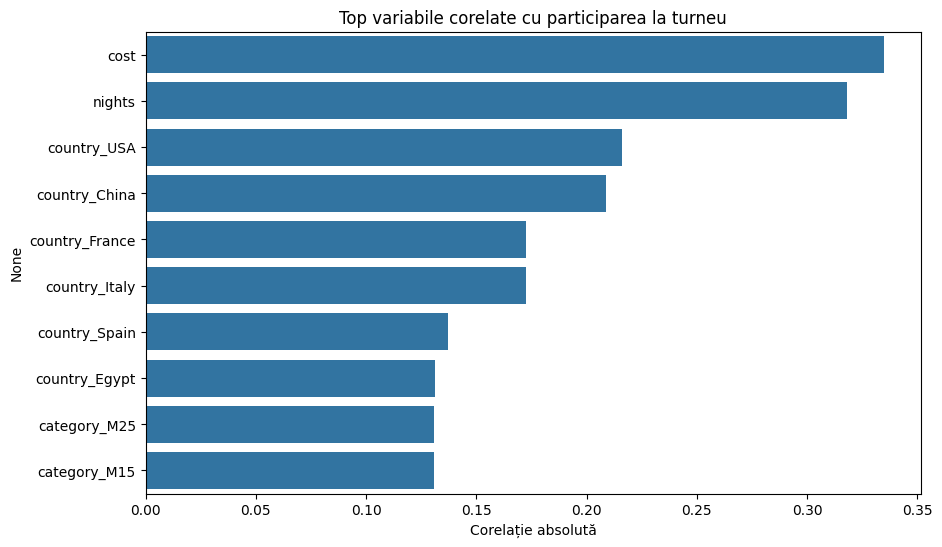

In [17]:
target_corr = X_encoded.corrwith(y)

target_corr = target_corr.abs().sort_values(ascending=False)

top_corr = target_corr.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top variabile corelate cu participarea la turneu")
plt.xlabel("Corelație absolută")

plt.show()

Graficul prezinta variabilele cu cea mai mare corelatie absoluta fata de participarea la turneu.

Observam că variabilele „cost” si „nights” au cele mai ridicate valori de corelatie, ceea ce sugereaza ca bugetul disponibil si durata deplasarii influentează semnificativ decizia unui jucator de a participa la un turneu.

De asemenea, anumite locatii ale turneelor, precum USA, China, Franta sau Italia, par sa fie asociate mai puternic cu participarea respondentilor, indicand faptul ca tara in care se desfasoara competitia poate avea un impact important asupra alegerii.

Categoria turneului (M15 si M25) apare si ea printre variabilele relevante, ceea ce sugereaza ca nivelul competitiei influenteaza interesul participantilor.

Valorile corelatiilor nu sunt foarte apropiate de 1, ceea ce indica faptul ca participarea la turneu nu depinde de o singura variabila, ci de combinatia mai multor factori.

***Corelatii intre variabile***

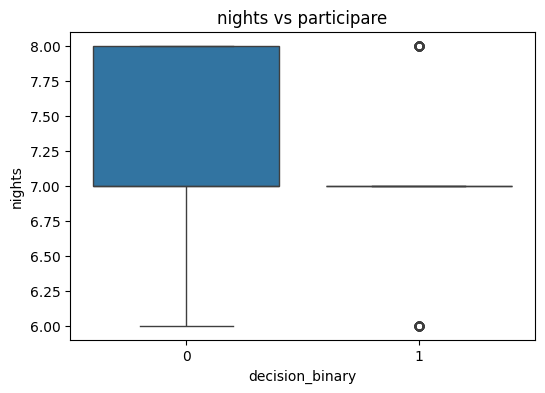

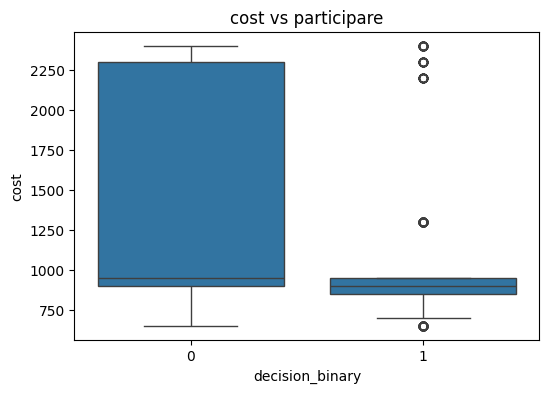

In [18]:
features_to_plot = [
    "nights",
    "cost",
]

for feature in features_to_plot:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=y,
        y=X_encoded[feature]
    )

    plt.title(f"{feature} vs participare")

    plt.show()

Graficul „nights vs participare” evidentiaza relatia dintre numarul de nopti necesare pentru deplasare si decizia de participare la turneu.

Observăm că valorile sunt concentrate în jurul intervalului 7–8 nopți pentru majoritatea respondentilor, indiferent de decizia finala. Totusi, exista si câteva valori izolate, ceea ce indica faptul ca anumite persoane sunt dispuse sa participe chiar si in cazul unor deplasari mai scurte sau mai lungi.

Distributia relativ apropiată dintre cele doua categorii sugereaza ca numarul de nopti influenteaza decizia de participare, insa nu reprezinta singurul factor determinant.

Graficul „cost vs participare” arata distributia costurilor estimate în functie de decizia de participare la turneu.

Se observa ca majoritatea respondentilor care aleg sa participe au costuri concentrate intr-un interval relativ apropiat, insa exista si cateva valori extreme pentru costuri ridicate. In cazul respondentilor care nu participa, distributia costurilor este mai dispersata si include valori mari mai frecvent.

Acest rezultat sugereaza ca bugetul si costurile deplasarii pot influenta semnificativ decizia de participare, costurile ridicate reprezentand un posibil factor de descurajare.

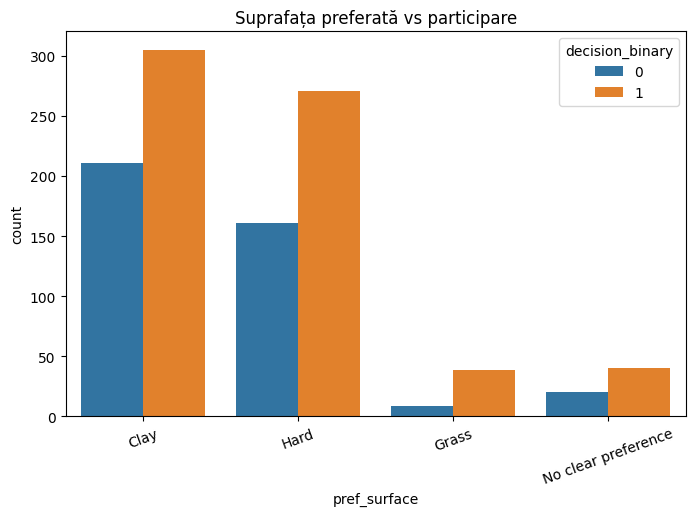

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["pref_surface"],
    hue=y
)

plt.title("Suprafața preferată vs participare")

plt.xticks(rotation=20)

plt.show()

Graficul evidentiaza relatia dintre suprafata preferata de joc si decizia de participare la turnee.

Se observa ca majoritatea respondentilor prefera suprafetele Clay si Hard, acestea avand si cel mai mare numar de participanti. In ambele cazuri, numarul persoanelor care aleg sa participe este mai mare decat al celor care nu participa.

Suprafata Grass este semnificativ mai putin preferata comparativ cu celelalte, avand un numar redus de respondenti. Totusi, chiar si in acest caz, se observa o tendinta mai mare spre participare decat spre neparticipare.

Categoria „No clear preference” include respondentii fara o preferinta clara pentru o anumita suprafata, iar distributia indica de asemenea o usoara predominanta a participantilor.

Rezultatele sugereaza ca preferinta pentru suprafata de joc poate influenta decizia de participare, suprafetele Clay si Hard fiind asociate cu un interes mai ridicat pentru competitii.

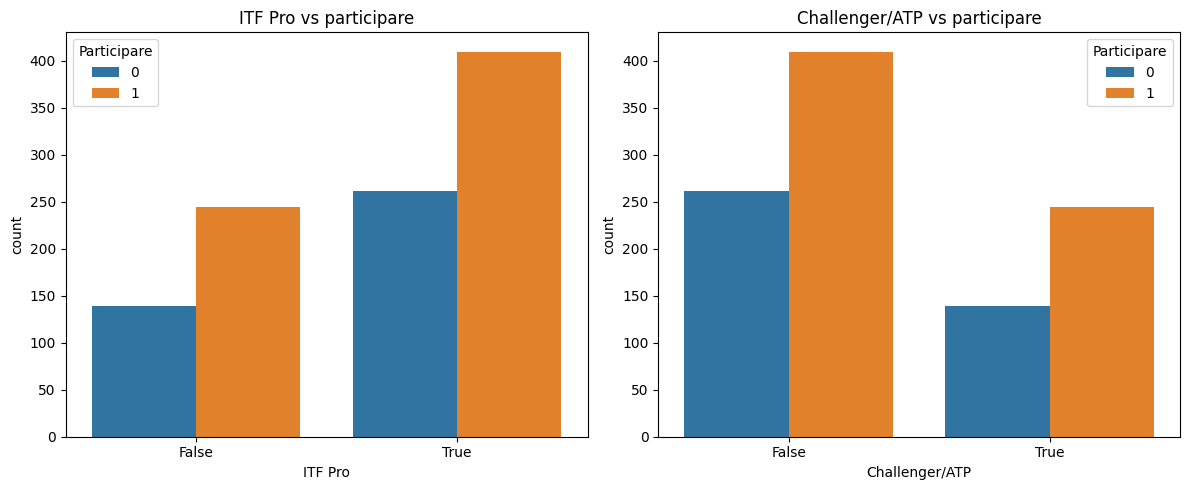

In [20]:
level_compare = pd.DataFrame({
    "Participare": y,
    "ITF Pro": X_encoded["level_ITF Pro"],
    "Challenger/ATP": X_encoded["level_Challenger/ATP"]
})

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    data=level_compare,
    x="ITF Pro",
    hue="Participare",
    ax=axes[0]
)

axes[0].set_title("ITF Pro vs participare")

sns.countplot(
    data=level_compare,
    x="Challenger/ATP",
    hue="Participare",
    ax=axes[1]
)

axes[1].set_title("Challenger/ATP vs participare")

plt.tight_layout()
plt.show()

Graficele prezinta relatia dintre nivelul sportiv al jucatorilor si decizia de participare la turnee.

In cazul categoriei ITF Pro, se observa ca majoritatea respondentilor apartin acestui nivel, iar numarul participantilor la turnee este mai mare decat al celor care nu participa. Acest lucru sugereaza ca jucatorii de nivel ITF Pro sunt mai inclinati sa participe la competitii.

Pentru categoria Challenger/ATP, numarul total de respondenti este mai redus comparativ cu ITF Pro. Totusi, si aici se observa ca participantii sunt mai numerosi decat neparticipantii.

Comparand cele doua grafice, se poate observa ca nivelul ITF Pro este predominant in dataset, in timp ce categoria Challenger/ATP reprezinta un grup mai restrans de jucatori.

Rezultatele indica faptul ca nivelul sportiv poate influenta decizia de participare la turnee si reprezinta o variabila relevanta pentru modelele de clasificare utilizate ulterior.

In [21]:
X_encoded.head()

,nights,cost,level_Challenger/ATP,level_ITF Pro,age_18-23,age_24-29,age_30-34,age_Over 35,age_Under 18,"budget_Over €30,000",...,country_Spain,country_Turkey,country_USA,category_M15,category_M25,surface_Clay,surface_Hard,period_April,period_February,period_March
0,7,850,False,True,True,False,False,False,False,False,...,False,True,False,True,False,True,False,False,False,True
1,7,1300,False,True,True,False,False,False,False,False,...,True,False,False,False,True,True,False,False,False,True
2,8,2300,False,True,True,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
3,7,900,False,True,True,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
4,7,700,False,True,True,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True


In [22]:
X_encoded.shape

(1056, 46)

Dupa aplicarea encoding-ului, numarul de coloane a crescut, deoarece fiecare categorie a fost transformata intr-o variabila separata.

#***TRAIN - TEST*** ***SPLIT***

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Datasetul a fost impartit in set de antrenament (80%) si set de test (20%), folosind stratificare pentru a pastra proportia claselor in ambele seturi.

In [24]:
X_train.shape, X_test.shape

((844, 46), (212, 46))

In [25]:
y_train.shape, y_test.shape

((844,), (212,))

Dupa aplicarea tehnicii de impartire a datelor, setul de antrenare contine 844 de observatii, iar setul de test 212 de observatii.

- set de antrenament: aprox. 80%
- set de test: aprox. 20%

#***Regresia Logistica***

Regresia Logistica este un algoritm de clasificare utilizat pentru probleme cu variabila tinta binara.

Modelul estimeaza probabilitatea apartenentei unei observatii la o anumita clasa utilizand o functie logistica (sigmoid). In cadrul acestei lucrari, regresia logistica este folosita pentru a prezice daca un jucator va participa sau nu la un turneu.

In [26]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

***Antrenare model***

Initial s-a incercat antrenarea modelului de regresie logistica folosind
libraria statsmodels, care ofera un sumar detaliat cu coeficienti si p-value.
Insa modelul nu a convergit, chiar si dupa aplicarea StandardScaler pe date.

Aceasta problema apare din cauza complexitatii datelor: datasetul contine
46 de variabile dupa one-hot encoding, multe dintre ele corelate intre ele
(multicolinearitate), ceea ce face ca optimizatorul din statsmodels sa nu
gaseasca o solutie stabila in numarul default de iteratii.

Din acest motiv, antrenarea modelului se va realiza folosind sklearn, care
foloseste un optimizer mai robust pentru date de acest tip. Pentru a obtine
coeficientii si p-value-urile asociate, acestea vor fi calculate manual
folosind libraria scipy, oferind informatii echivalente cu sumarul statsmodels.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score

log_model = LogisticRegression(max_iter=5000, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    log_model,
    X_train,
    y_train,
    cv=kf,
    scoring='accuracy'
)

# Antrenam modelul final pe tot X_train
log_model.fit(X_train, y_train)

print("Model antrenat cu succes!")
print(f"Numar iteratii: {log_model.n_iter_[0]}")
print(f"\n5-Fold CV Scoruri: {cv_scores}")
print(f"Medie CV: {cv_scores.mean():.4f}")
print(f"Std CV:   {cv_scores.std():.4f}")

Model antrenat cu succes!
Numar iteratii: 1396

5-Fold CV Scoruri: [0.65680473 0.70414201 0.64497041 0.67455621 0.7797619 ]
Medie CV: 0.6920
Std CV:   0.0482


Validarea incrucisata cu 5 fold-uri a fost realizata exclusiv pe setul
de antrenament, fara a atinge setul de test.

Scorurile obtinute pe cele 5 fold-uri sunt:
[0.6568, 0.7041, 0.6450, 0.6746, 0.7798]

Scorul mediu de 69.20% indica o performanta moderata a modelului pe
date nevazute in timpul antrenarii.

Deviatia standard de 0.0482 arata ca performanta variaza putin intre
fold-uri, ceea ce sugereaza ca modelul este relativ stabil si nu depinde
excesiv de un anumit subset de date.

Dupa validare, modelul final a fost antrenat pe intregul set de
antrenament (844 de observatii), necesitand 1396 de iteratii pentru
a converge.

***Learning Curve***

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

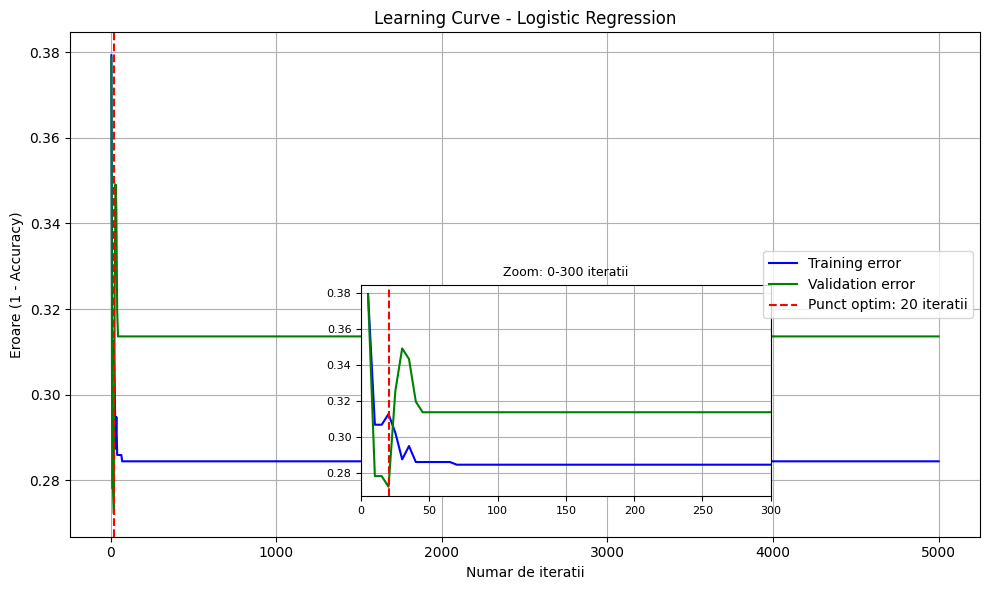

Punctul optim: 20 iteratii
Training error la punct optim: 0.3126
Validation error la punct optim: 0.2722
Training error la 5000 iteratii: 0.2844
Validation error la 5000 iteratii: 0.3136


In [28]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Split intern de validare, exclusiv din X_train (setul de test nu este folosit)
X_tr_lc, X_val_lc, y_tr_lc, y_val_lc = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Pasii de iteratii la care evaluam modelul
iter_steps = list(range(5, 5001, 5))

train_errors = []
val_errors = []

log_model_lc = LogisticRegression(C=1, max_iter=1, warm_start=True,
                                   solver='lbfgs', random_state=42)

for n_iter in iter_steps:
    log_model_lc.max_iter = n_iter
    log_model_lc.fit(X_tr_lc, y_tr_lc)

    train_acc = log_model_lc.score(X_tr_lc, y_tr_lc)
    val_acc = log_model_lc.score(X_val_lc, y_val_lc)

    train_errors.append(1 - train_acc)
    val_errors.append(1 - val_acc)

train_errors = np.array(train_errors)
val_errors = np.array(val_errors)

# Punctul optim - unde eroarea de validare este minima
optimal_idx = np.argmin(val_errors)
optimal_iter = iter_steps[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(iter_steps, train_errors, label='Training error', color='blue')
ax.plot(iter_steps, val_errors, label='Validation error', color='green')

ax.axvline(x=optimal_iter, color='red', linestyle='--',
           label=f'Punct optim: {optimal_iter} iteratii')

ax.set_xlabel('Numar de iteratii')
ax.set_ylabel('Eroare (1 - Accuracy)')
ax.set_title('Learning Curve - Logistic Regression')
ax.legend(loc='center right')
ax.grid(True)

# Inset cu zoom pe zona de tranzitie (0-300 iteratii)
axins = ax.inset_axes([0.32, 0.08, 0.45, 0.42])
zoom_max = 300
n_zoom = zoom_max // 5
axins.plot(iter_steps[:n_zoom], train_errors[:n_zoom], color='blue')
axins.plot(iter_steps[:n_zoom], val_errors[:n_zoom], color='green')
axins.axvline(x=optimal_iter, color='red', linestyle='--')
axins.set_xlim(0, zoom_max)
axins.set_title('Zoom: 0-300 iteratii', fontsize=9)
axins.tick_params(labelsize=8)
axins.grid(True)

plt.tight_layout()
plt.show()

print(f"Punctul optim: {optimal_iter} iteratii")
print(f"Training error la punct optim: {train_errors[optimal_idx]:.4f}")
print(f"Validation error la punct optim: {val_errors[optimal_idx]:.4f}")
print(f"Training error la 5000 iteratii: {train_errors[-1]:.4f}")
print(f"Validation error la 5000 iteratii: {val_errors[-1]:.4f}")

Graficul de invatare evidentiaza evolutia erorii de antrenament si de
validare in functie de numarul de iteratii ale algoritmului de optimizare
(lbfgs), permitand identificarea momentului in care apare overfitting-ul,
similar abordarii folosite la XGBoost si la reteaua neuronala.

Eroarea de validare atinge minimul de 0.2722 la doar 20 de iteratii, in
timp ce eroarea de antrenament este inca ridicata (0.3126) in acest punct.
Dupa acest punct, eroarea de antrenament continua sa scada (ajungand la
0.2859 la 5000 de iteratii), in timp ce eroarea de validare creste si se
stabilizeaza in jurul valorii de 0.3136. Acest comportament indica un
fenomen modest de overfitting: modelul continua sa se ajusteze la datele
de antrenament dincolo de 20 de iteratii, fara ca aceasta ajustare
suplimentara sa aduca beneficii pe date nevazute.

Cu toate acestea, modelul final a fost antrenat cu max_iter=5000 (convergenta
efectiva la 1396 de iteratii), deoarece diferenta dintre eroarea de validare
la punctul optim (0.2722) si cea de la convergenta completa (0.3136) este
mica in termeni absoluti (~4 puncte procentuale), iar oprirea prematura la
20 de iteratii ar produce un model insuficient ajustat (underfitting), cu
coeficienti instabili. Amplitudinea redusa a acestui gap confirma totodata
ca regresia logistica, fiind un model liniar cu capacitate de reprezentare
limitata, nu poate exploata suplimentar complexitatea datelor, indiferent
de numarul de iteratii alocat.

***GridSearch CV***

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    param_grid,
    cv=kf,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Rezultate pentru fiecare valoare de C:")
for mean, param in zip(grid_search.cv_results_['mean_test_score'],
                       grid_search.cv_results_['params']):
    print(f"  C={param['C']}: accuracy={mean:.4f}")

print(f"\nCel mai bun C: {grid_search.best_params_['C']}")
print(f"Cel mai bun scor CV: {grid_search.best_score_:.4f}")

log_model = grid_search.best_estimator_

Rezultate pentru fiecare valoare de C:
  C=0.001: accuracy=0.6991
  C=0.01: accuracy=0.6991
  C=0.1: accuracy=0.6837
  C=1: accuracy=0.6920
  C=10: accuracy=0.6920
  C=100: accuracy=0.6920

Cel mai bun C: 0.001
Cel mai bun scor CV: 0.6991


Pentru optimizarea modelului de regresie logistica, a fost testat
parametrul de regularizare C pe urmatoarele valori: 0.001, 0.01,
0.1, 1, 10, 100.

Parametrul C controleaza intensitatea regularizarii:
- C mic (ex: 0.001): regularizare puternica, model mai simplu
- C mare (ex: 100): regularizare slaba, model mai complex

Rezultatele obtinute prin 5-Fold CV:
- C=0.001: 0.6991
- C=0.01:  0.6991
- C=0.1:   0.6837
- C=1:     0.6920
- C=10:    0.6920
- C=100:   0.6920

Cel mai bun rezultat a fost obtinut cu C=0.001 (accuracy=0.6991),
ceea ce indica ca o regularizare puternica ajuta modelul sa
generalizeze mai bine pe datele noastre cu multe variabile categoriale.

Modelul final va fi antrenat cu C=0.001.

***Reantrenare cu C=0.001***

In [30]:
# Reantrenam cu cel mai bun parametru gasit
log_model = LogisticRegression(C=0.001, max_iter=5000, random_state=42)

cv_scores_best = cross_val_score(
    log_model,
    X_train,
    y_train,
    cv=kf,
    scoring='accuracy'
)

log_model.fit(X_train, y_train)

print("Model reantrenat cu C=0.001!")
print(f"\n5-Fold CV Scoruri: {cv_scores_best}")
print(f"Medie CV model optimizat: {cv_scores_best.mean():.4f}")
print(f"Medie CV model initial:   {cv_scores.mean():.4f}")

Model reantrenat cu C=0.001!

5-Fold CV Scoruri: [0.70414201 0.66272189 0.68047337 0.68047337 0.76785714]
Medie CV model optimizat: 0.6991
Medie CV model initial:   0.6920


Dupa identificarea celui mai bun parametru de regularizare prin
GridSearchCV, modelul a fost reantrenat cu C=0.001.

Scorul mediu CV a crescut de la 0.6920 (model initial cu C=1)
la 0.6991 (model optimizat cu C=0.001), o imbunatatire de
aproximativ 0.7%.

Regularizarea puternica (C mic) reduce complexitatea modelului
si previne overfitting-ul, ceea ce explica performanta mai buna
pe datele de validare.

Modelul optimizat cu C=0.001 va fi folosit pentru toate
evaluarile urmatoare.

***Observatii dupa evaluarea modelului cu C=0.001***

Desi GridSearchCV a identificat C=0.001 ca parametru optim
pe baza scorului CV (0.6991 vs 0.6920), validarea incrucisata
cu C=0.001 a aratat un echilibru mai slab intre clase comparativ
cu valoarea default C=1.

Acest lucru ilustreaza o situatie frecventa in practica:
scorul mediu CV poate favoriza un parametru care nu generalizeaza
la fel de bine pe date noi.

Prin urmare, pentru evaluarea finala se va folosi modelul
cu C=1 (valoarea default), care ofera rezultate mai stabile
si un echilibru mai bun intre cele doua clase pe validare.

In [31]:
log_model = LogisticRegression(C=1, max_iter=5000, random_state=42)
log_model.fit(X_train, y_train)
print("Model final antrenat cu C=1!")

Model final antrenat cu C=1!


***Feature Importance***

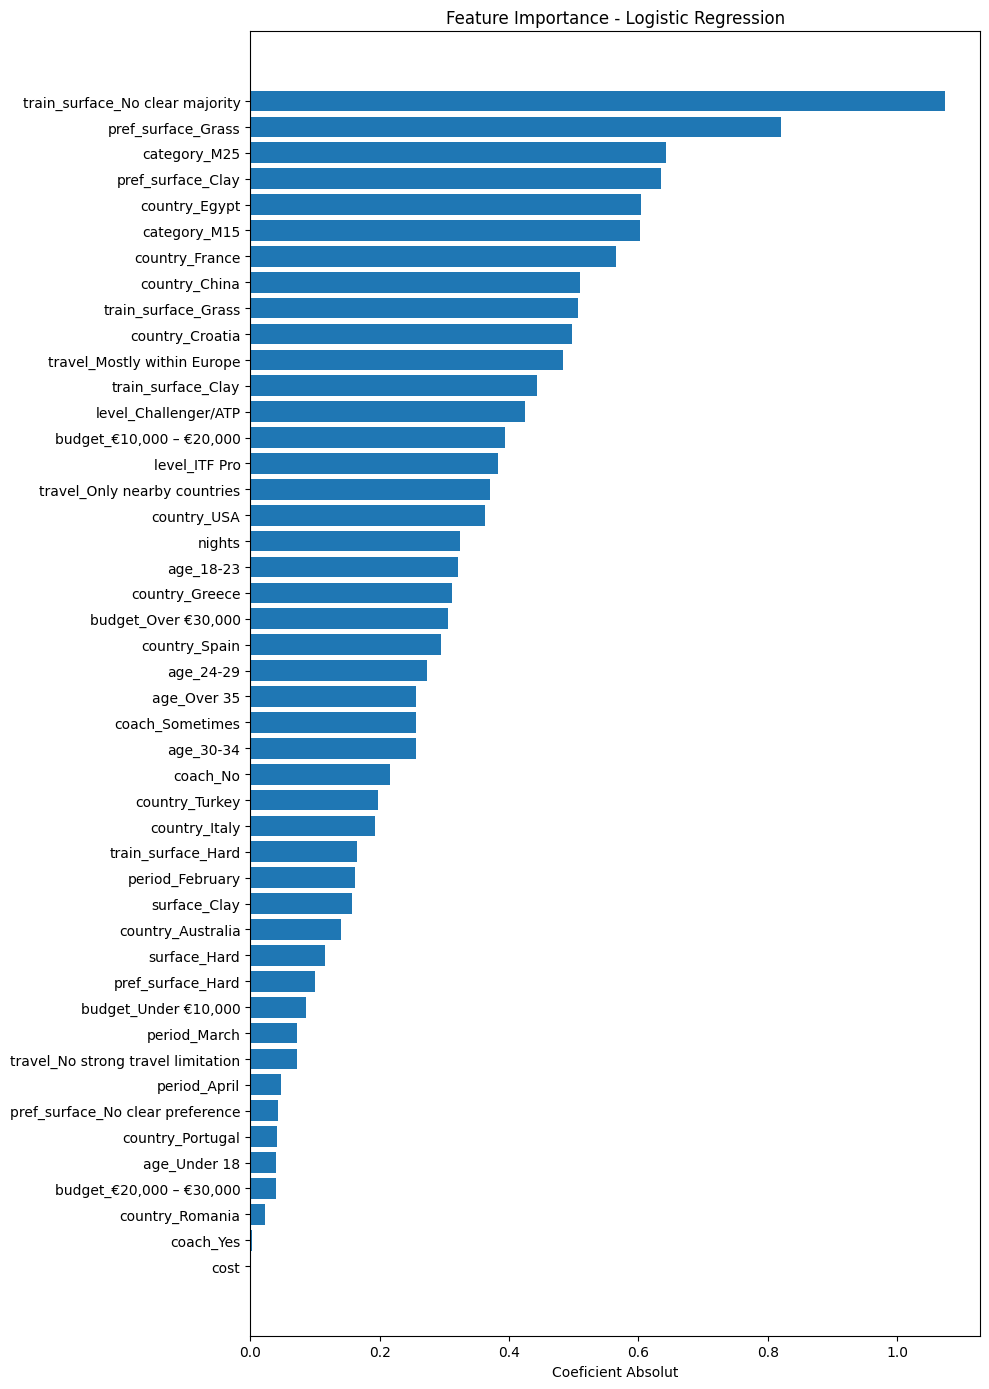

                           Feature  Coeficient  Abs_Coeficient
   train_surface_No clear majority   -1.074052        1.074052
                pref_surface_Grass    0.820881        0.820881
                      category_M25    0.642950        0.642950
                 pref_surface_Clay   -0.635033        0.635033
                     country_Egypt   -0.604157        0.604157
                      category_M15   -0.601586        0.601586
                    country_France    0.565436        0.565436
                     country_China   -0.509727        0.509727
               train_surface_Grass    0.506985        0.506985
                   country_Croatia   -0.497156        0.497156
       travel_Mostly within Europe    0.483243        0.483243
                train_surface_Clay    0.443469        0.443469
              level_Challenger/ATP    0.424281        0.424281
          budget_€10,000 – €20,000    0.393901        0.393901
                     level_ITF Pro   -0.382917        0

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficient': log_model.coef_[0],
    'Abs_Coeficient': np.abs(log_model.coef_[0])
})

importance_df = importance_df.sort_values(by='Abs_Coeficient', ascending=False)

plt.figure(figsize=(10, 14))
plt.barh(importance_df['Feature'], importance_df['Abs_Coeficient'])
plt.gca().invert_yaxis()
plt.xlabel('Coeficient Absolut')
plt.title('Feature Importance - Logistic Regression')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

Importanta variabilelor a fost calculata pe baza valorii absolute a
coeficientilor modelului de regresie logistica cu C=1.

Cele mai importante variabile sunt train_surface_No clear majority
(1.074), pref_surface_Grass (0.821) si category_M25 (0.643),
care au coeficienti absoluti mari, indicand o influenta puternica
asupra deciziei de participare.

Variabilele cu coeficient absolut mic (sub 0.05) precum cost,
coach_Yes si country_Romania contribuie foarte putin la predictie.

Cu toate acestea, avand in vedere ca regularizarea cu C=1 nu
comprima coeficientii excesiv, toate variabilele sunt pastrate
in model deoarece eliminarile testate anterior nu au adus
imbunatatiri ale performantei.

***Predictii pe Validare***

In [33]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(
    log_model,
    X_train,
    y_train,
    cv=kf
)

***Matricea de confuzie***

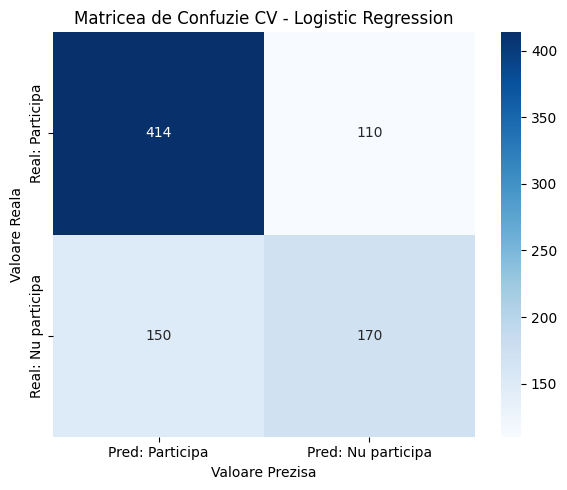

True Positive  (Participa corect):         414
False Negative (Participa gresit ca Nu):   110
False Positive (Nu participa gresit ca Da):150
True Negative  (Nu participa corect):      170


In [34]:
cm = confusion_matrix(y_train, y_pred_cv, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie CV - Logistic Regression')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm.ravel()
print(f"True Positive  (Participa corect):         {tp}")
print(f"False Negative (Participa gresit ca Nu):   {fn}")
print(f"False Positive (Nu participa gresit ca Da):{fp}")
print(f"True Negative  (Nu participa corect):      {tn}")

Matricea de confuzie este calculata pe baza predictiilor din
cross-validare (844 observatii din setul de antrenament).

True Positive (414): jucatori care participa, corect identificati
False Negative (110): jucatori care participa, gresit prezisi ca Nu participa
False Positive (150): jucatori care nu participa, gresit prezisi ca Participa
True Negative (170): jucatori care nu participa, corect identificati

Modelul identifica corect 414 din 524 cazuri de participare (recall 79%)
si 170 din 320 cazuri de neparticipare (recall 53%).

Se observa ca modelul are dificultati in identificarea cazurilor
de neparticipare, cu 150 de false positive, ceea ce sugereaza
o tendinta de a prezice participarea mai des decat neparticiparea.

***Classification Report***

In [35]:
print(classification_report(
    y_train,
    y_pred_cv,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.61      0.53      0.57       320
Nu participa (0)       0.73      0.79      0.76       524

        accuracy                           0.69       844
       macro avg       0.67      0.66      0.66       844
    weighted avg       0.69      0.69      0.69       844



Classification report-ul pe cross-validare arata performanta
modelului de regresie logistica pe setul de antrenament (844 observatii).

Clasa Participa (1):
- Precision 0.61: din toti jucatorii prezisi ca participa,
  61% chiar participa
- Recall 0.53: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 53%
- F1-score 0.57

Clasa Nu participa (0):
- Precision 0.73: din toti jucatorii prezisi ca nu participa,
  73% chiar nu participa
- Recall 0.79: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 79%
- F1-score 0.76

Acuratetea generala pe CV este de 69%, consistenta cu scorul
mediu obtinut prin 5-Fold CV (0.6920). Modelul performa mai
bine pe clasa Nu participa, indicand o dificultate mai mare
in identificarea jucatorilor care aleg sa participe.

***Curba ROC***

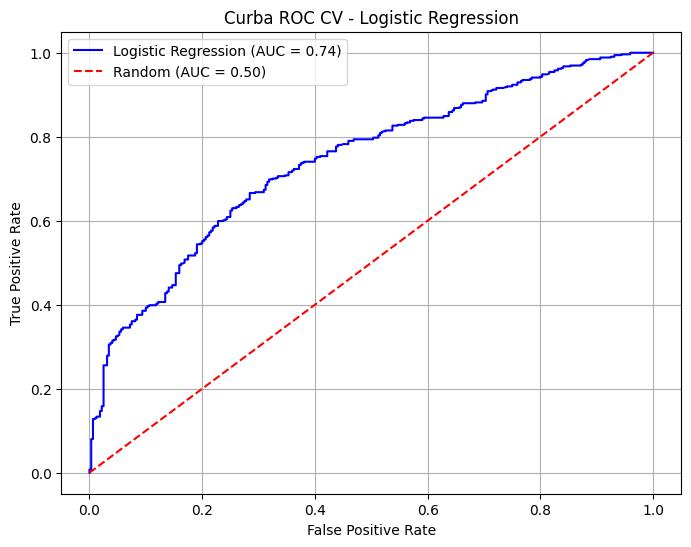

AUC: 0.7420


In [36]:
y_prob_cv = cross_val_predict(
    log_model,
    X_train,
    y_train,
    cv=kf,
    method='predict_proba'
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train, y_prob_cv)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curba ROC CV - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.4f}")

Curba ROC pe cross-validare evalueaza capacitatea modelului de
a discrimina intre cele doua clase pe setul de antrenament.

Valoarea AUC de 0.74 indica o capacitate buna a modelului.
Aceasta valoare este mai mica decat cea obtinuta anterior
deoarece CV-ul evalueaza modelul pe date nevazute in fiecare
fold, oferind o estimare mai realista a performantei.

Cu AUC = 0.74, modelul de regresie logistica se incadreaza
in categoria modelelor bune, fiind o baza solida de comparatie
pentru modelele mai complexe care urmeaza.

***Test final***

In [37]:
y_pred_test = log_model.predict(X_test)
y_prob_test = log_model.predict_proba(X_test)[:, 1]

***Matricea de confuzie pe test***

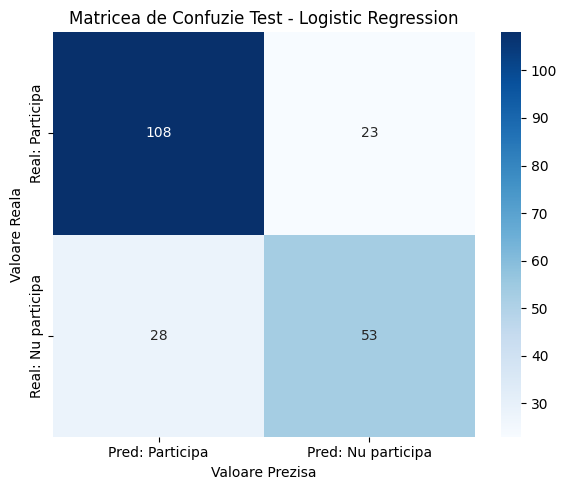

True Positive  (Participa corect):          108
False Negative (Participa gresit ca Nu):    23
False Positive (Nu participa gresit ca Da): 28
True Negative  (Nu participa corect):       53


In [38]:
cm_test = confusion_matrix(y_test, y_pred_test, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie Test - Logistic Regression')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm_test.ravel()
print(f"True Positive  (Participa corect):          {tp}")
print(f"False Negative (Participa gresit ca Nu):    {fn}")
print(f"False Positive (Nu participa gresit ca Da): {fp}")
print(f"True Negative  (Nu participa corect):       {tn}")

Matricea de confuzie pe setul de test (212 observatii) confirma
performanta modelului final de regresie logistica pe date complet
nevazute in timpul antrenarii.

True Positive (108): jucatori care participa, corect identificati
False Negative (23): jucatori care participa, gresit prezisi ca Nu participa
False Positive (28): jucatori care nu participa, gresit prezisi ca Participa
True Negative (53): jucatori care nu participa, corect identificati

Rezultatele sunt consistente cu cele obtinute prin cross-validare,
confirmand ca modelul generalizeaza bine pe date noi si nu face
overfitting pe setul de antrenament.

***Classification Report pe test***

In [39]:
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.70      0.65      0.68        81
Nu participa (0)       0.79      0.82      0.81       131

        accuracy                           0.76       212
       macro avg       0.75      0.74      0.74       212
    weighted avg       0.76      0.76      0.76       212



Classification report-ul pe setul de test confirma performanta
modelului final de regresie logistica pe 212 observatii nevazute.

Clasa Participa (1):
- Precision 0.70: din toti jucatorii prezisi ca participa,
  70% chiar participa
- Recall 0.65: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 65%
- F1-score 0.68

Clasa Nu participa (0):
- Precision 0.79: din toti jucatorii prezisi ca nu participa,
  79% chiar nu participa
- Recall 0.82: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 82%
- F1-score 0.81

Acuratetea pe setul de test este de 76%, superioara celei
obtinute prin CV (69%), ceea ce confirma ca modelul
generalizeaza bine pe date noi.

***Curba ROC pe test***

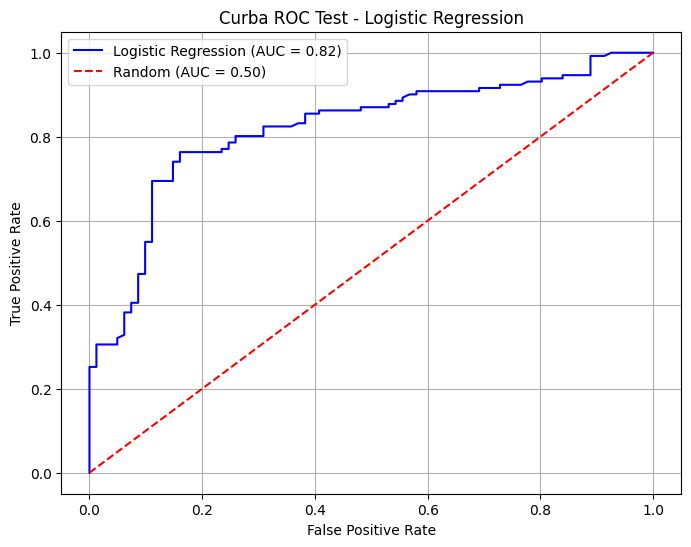

AUC: 0.8200


In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curba ROC Test - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.4f}")

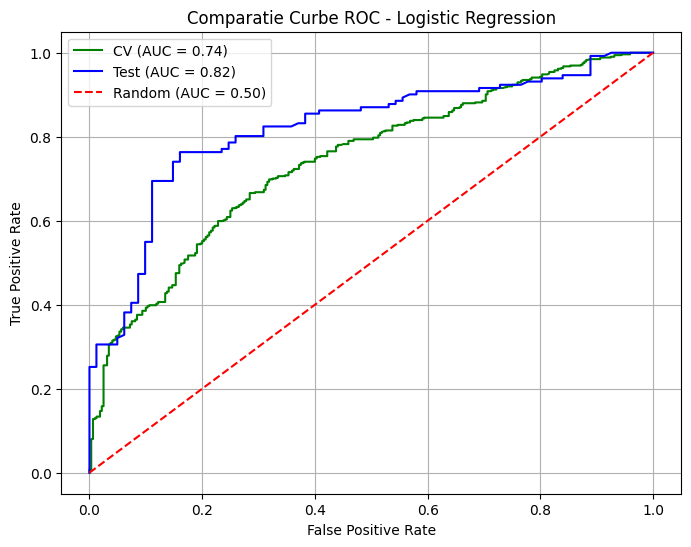

In [41]:
# Curba ROC CV
y_prob_cv = cross_val_predict(
    log_model,
    X_train,
    y_train,
    cv=kf,
    method='predict_proba'
)[:, 1]

fpr_cv, tpr_cv, _ = roc_curve(y_train, y_prob_cv)
auc_cv = auc(fpr_cv, tpr_cv)

# Curba ROC Test
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cv, tpr_cv, color='green', label=f'CV (AUC = {auc_cv:.2f})')
plt.plot(fpr_test, tpr_test, color='blue', label=f'Test (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparatie Curbe ROC - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

Curba ROC pe setul de test confirma performanta modelului final
de regresie logistica pe date complet nevazute.

Valoarea AUC de 0.82 este superioara celei obtinute prin CV
(0.74), indicand ca modelul generalizeaza foarte bine pe date noi.

Cu AUC = 0.82, modelul de regresie logistica se incadreaza
in categoria modelelor foarte bune. Aceasta valoare va fi
folosita pentru comparatia finala cu celelalte modele.

***Concluzii***

Modelul de regresie logistica a obtinut o acuratete de 76% pe
setul de test si un AUC de 0.82, incadrandu-se in categoria
modelelor foarte bune.

Prin procesul de tuning cu GridSearchCV au fost testati mai multi
parametri de regularizare C, insa modelul cu valoarea default
C=1 a oferit cel mai bun echilibru intre cele doua clase.

Modelul performa mai bine pe clasa Nu participa (F1=0.81) decat
pe clasa Participa (F1=0.68), ceea ce sugereaza ca factorii care
determina neparticiparea sunt mai usor de capturat de un model liniar.

Desi regresia logistica ofera rezultate bune si este usor de
interpretat, natura liniara a modelului limiteaza capacitatea
sa de a capta relatii mai complexe dintre variabile. Modelele
urmatoare bazate pe arbori de decizie pot oferi o performanta
superioara pe acest dataset.

#***Decision Tree***

Arborii de decizie sunt modele de clasificare usor de interpretat, deoarece iau decizii prin impartirea succesiva a datelor in functie de valorile variabilelor explicative.

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Arbore fara restrictii - baseline
tree_model = DecisionTreeClassifier(random_state=42)

cv_scores_tree = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=kf,
    scoring='accuracy'
)

tree_model.fit(X_train, y_train)

print("Model antrenat cu succes!")
print(f"Adancime arbore: {tree_model.get_depth()}")
print(f"Numar frunze: {tree_model.tree_.n_leaves}")
print(f"\n5-Fold CV Scoruri: {cv_scores_tree}")
print(f"Medie CV: {cv_scores_tree.mean():.4f}")
print(f"Std CV:   {cv_scores_tree.std():.4f}")

Model antrenat cu succes!
Adancime arbore: 17
Numar frunze: 188

5-Fold CV Scoruri: [0.82840237 0.81656805 0.82248521 0.81656805 0.83928571]
Medie CV: 0.8247
Std CV:   0.0085


Arborele de decizie fara restrictii a fost antrenat ca punct de
plecare (baseline) pentru procesul de optimizare.

Arborele initial are o adancime de 17 si 188 de frunze, ceea ce
indica un model foarte complex care risca sa faca overfitting
pe datele de antrenament.

Scorul mediu CV de 82.47% este superior regresiei logistice
(69.20%), indicand ca arborii de decizie capteaza mai bine
relatiile neliniare din date.

Deviatia standard mica de 0.0085 arata ca performanta este
stabila pe toate cele 5 fold-uri. In pasii urmatori vom aplica
tehnici de pruning pentru a reduce complexitatea arborelui
si a imbunatati generalizarea.

***Learning Curve***

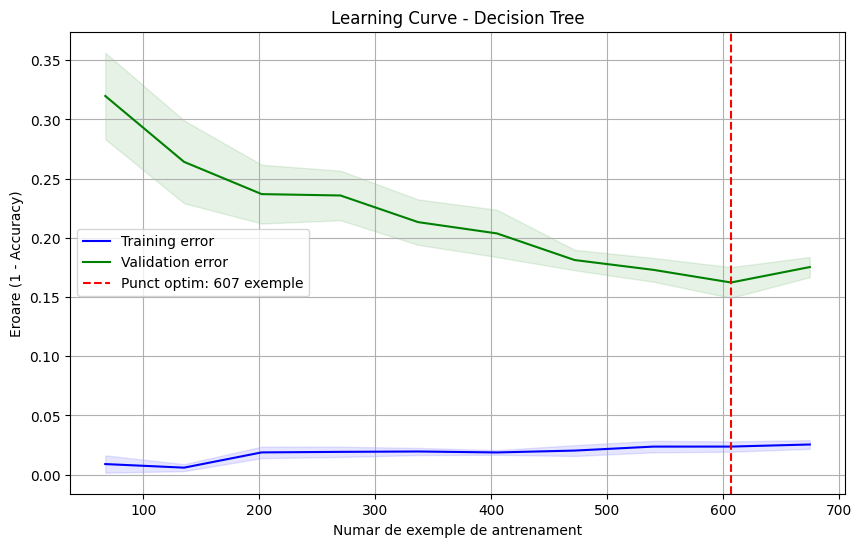

Punctul optim: 607 exemple
Training error la punct optim: 0.0237
Validation error la punct optim: 0.1623


In [43]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    tree_model,
    X_train,
    y_train,
    cv=kf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_error_mean = 1 - train_scores.mean(axis=1)
train_error_std = train_scores.std(axis=1)
val_error_mean = 1 - val_scores.mean(axis=1)
val_error_std = val_scores.std(axis=1)

# Punct optim - unde validation error e minima
optimal_idx = np.argmin(val_error_mean)
optimal_size = train_sizes[optimal_idx]

plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_error_mean, label='Training error', color='blue')
plt.fill_between(train_sizes, train_error_mean - train_error_std, train_error_mean + train_error_std, alpha=0.1, color='blue')

plt.plot(train_sizes, val_error_mean, label='Validation error', color='green')
plt.fill_between(train_sizes, val_error_mean - val_error_std, val_error_mean + val_error_std, alpha=0.1, color='green')

plt.axvline(x=optimal_size, color='red', linestyle='--', label=f'Punct optim: {optimal_size} exemple')

plt.xlabel('Numar de exemple de antrenament')
plt.ylabel('Eroare (1 - Accuracy)')
plt.title('Learning Curve - Decision Tree')
plt.legend()
plt.grid(True)
plt.show()

print(f"Punctul optim: {optimal_size} exemple")
print(f"Training error la punct optim: {train_error_mean[optimal_idx]:.4f}")
print(f"Validation error la punct optim: {val_error_mean[optimal_idx]:.4f}")

Graficul de invatare evidentiaza clar prezenta overfitting-ului
in arborele de decizie fara restrictii.

Training error este aproape 0 (0.02), ceeaa ce inseamna ca
modelul memoreaza aproape perfect datele de antrenament.
Validation error insa ramane ridicata (~0.16-0.32), indicand
ca modelul nu generalizeaza bine pe date nevazute.

Gap-ul mare dintre cele doua curbe confirma necesitatea
aplicarii tehnicilor de pruning pentru a reduce complexitatea
arborelui si a imbunatati generalizarea.

Punctul optim identificat este la 607 exemple, unde validation
error atinge valoarea minima de aproximativ 0.16.

***GridSearch CV***

In [44]:
from sklearn.model_selection import GridSearchCV

ccp_path = tree_model.cost_complexity_pruning_path(X_train, y_train)

alphas = ccp_path.ccp_alphas

param_grid = {
    'ccp_alpha': alphas,
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [6, 8, 12],
    'min_samples_split': [10, 20, 30],
    'criterion': ['gini', 'entropy']
}

grid_search_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=kf,
    scoring='accuracy'
)

grid_search_tree.fit(X_train, y_train)

print(f"Cei mai buni parametri: {grid_search_tree.best_params_}")
print(f"Cel mai bun scor CV: {grid_search_tree.best_score_:.4f}")

best_tree = grid_search_tree.best_estimator_
print(f"Adancime arbore optim: {best_tree.get_depth()}")
print(f"Numar frunze arbore optim: {best_tree.tree_.n_leaves}")

Cei mai buni parametri: {'ccp_alpha': np.float64(0.0), 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 10}
Cel mai bun scor CV: 0.8152
Adancime arbore optim: 5
Numar frunze arbore optim: 25


GridSearchCV a testat combinatii multiple de parametri pentru
a gasi arborele de decizie optim folosind 5-Fold CV.

Cei mai buni parametri identificati sunt:
- criterion: entropy
- max_depth: 5
- min_samples_leaf: 8
- min_samples_split: 10
- ccp_alpha: 0.0

Valoarea ccp_alpha = 0.0 indica faptul ca pruning-ul prin
cost complexity nu a adus imbunatatiri in cazul datelor noastre.
Restrictiile de adancime si numarul minim de exemple per frunza
sunt suficiente pentru a controla complexitatea arborelui.

Arborele optim are adancime 5 si 25 de frunze, mult mai simplu
decat arborele initial (adancime 17, 188 frunze), reducand
semnificativ riscul de overfitting.

Scorul CV de 0.8152 este superior regresiei logistice (0.6920),
confirmand ca arborele de decizie capteaza mai bine relatiile
neliniare dintre variabilele din dataset.

***Vizualizare arbore***

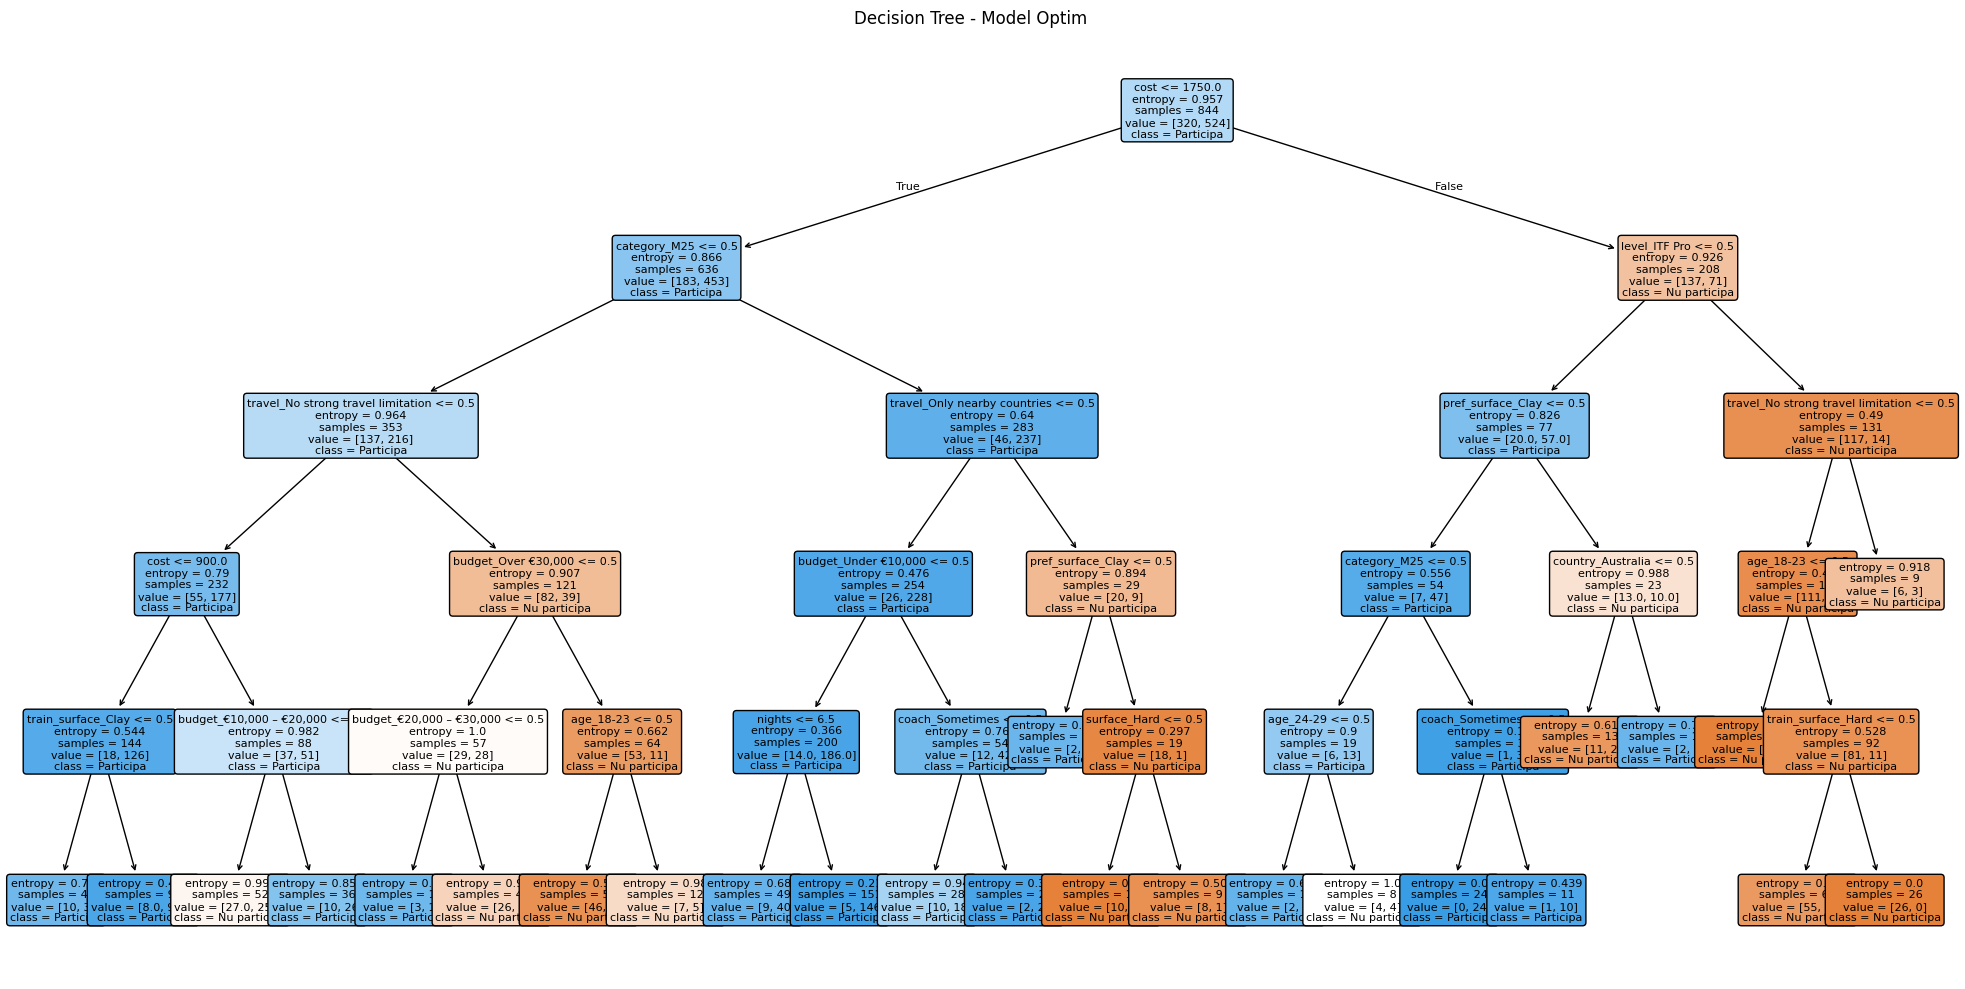

In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree,
    feature_names=list(X_train.columns),
    class_names=['Nu participa', 'Participa'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree - Model Optim')
plt.tight_layout()
plt.show()

Vizualizarea arborelui de decizie optim arata cum modelul
imparte datele in functie de variabilele cele mai relevante.

Nodul radacina imparte datele dupa variabila cost <= 1750,
sugerand ca costul turneului este factorul principal in
decizia de participare.

Nodurile albastre reprezinta clasa Participa, iar nodurile
portocalii reprezinta clasa Nu participa. Intensitatea
culorii indica puritatea nodului — cu cat culoarea e mai
intensa, cu atat nodul e mai pur.

Arborele are adancime 5 si 25 de frunze, ceea ce il face
suficient de complex pentru a capta relatiile din date,
dar suficient de simplu pentru a generaliza bine pe
date nevazute.

Variabilele cele mai importante la primele niveluri sunt
cost, category_M25 si level_ITF Pro, confirmand ca
factorii financiari si nivelul turneului influenteaza
cel mai mult decizia de participare.

***Learning Curve pe noul model***

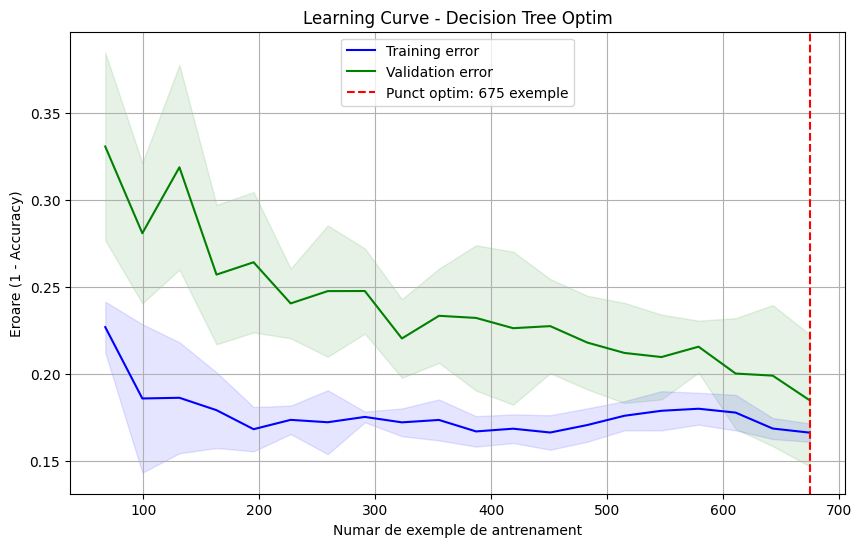

Punctul optim: 675 exemple
Training error: 0.1662
Validation error: 0.1848


In [46]:
train_sizes, train_scores, val_scores = learning_curve(
    best_tree,
    X_train,
    y_train,
    cv=kf,
    train_sizes=np.linspace(0.1, 1.0, 20),
    scoring='accuracy'
)

train_error_mean = 1 - train_scores.mean(axis=1)
val_error_mean = 1 - val_scores.mean(axis=1)
train_error_std = train_scores.std(axis=1)
val_error_std = val_scores.std(axis=1)

optimal_idx = np.argmin(val_error_mean)
optimal_size = train_sizes[optimal_idx]

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_error_mean, label='Training error', color='blue')
plt.fill_between(train_sizes, train_error_mean - train_error_std, train_error_mean + train_error_std, alpha=0.1, color='blue')
plt.plot(train_sizes, val_error_mean, label='Validation error', color='green')
plt.fill_between(train_sizes, val_error_mean - val_error_std, val_error_mean + val_error_std, alpha=0.1, color='green')
plt.axvline(x=optimal_size, color='red', linestyle='--', label=f'Punct optim: {optimal_size} exemple')
plt.xlabel('Numar de exemple de antrenament')
plt.ylabel('Eroare (1 - Accuracy)')
plt.title('Learning Curve - Decision Tree Optim')
plt.legend()
plt.grid(True)
plt.show()

print(f"Punctul optim: {optimal_size} exemple")
print(f"Training error: {train_error_mean[optimal_idx]:.4f}")
print(f"Validation error: {val_error_mean[optimal_idx]:.4f}")

Comparativ cu arborele initial, modelul optim prezinta un gap
mult mai mic intre training error (~0.17) si validation error
(~0.18), ceea ce confirma ca pruning-ul a redus semnificativ
overfitting-ul.

Validation error continua sa scada usor pana la capatul
graficului (675 exemple), fara sa arate semne de crestere.
Aceasta indica faptul ca modelul ar beneficia de mai multe
date de antrenament pentru a generaliza si mai bine.

Aceasta este o limitare a datasetului disponibil, nu o
problema a modelului. Cu mai multe date colectate prin
chestionar, performanta modelului ar putea creste.

Punctul optim identificat este la 675 exemple, cu o
validation error de 0.1848, echivalenta cu o acuratete
de aproximativ 81.5% pe datele de validare.

***Feature Importance***

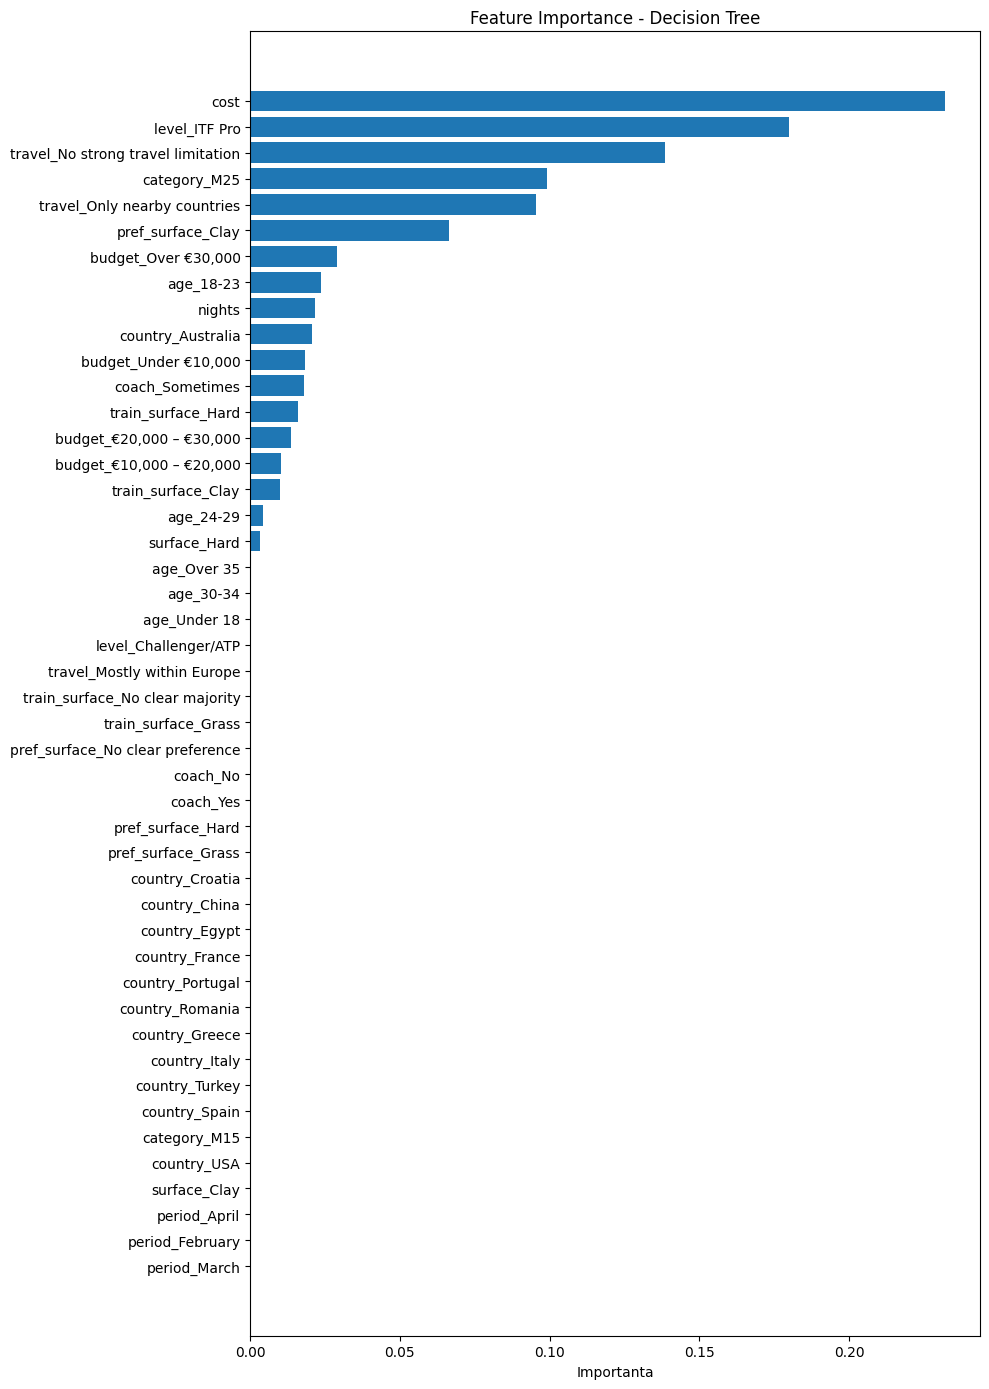

                           Feature  Importance
                              cost    0.232117
                     level_ITF Pro    0.180093
travel_No strong travel limitation    0.138377
                      category_M25    0.099215
      travel_Only nearby countries    0.095371
                 pref_surface_Clay    0.066489
               budget_Over €30,000    0.028864
                         age_18-23    0.023663
                            nights    0.021679
                 country_Australia    0.020707
              budget_Under €10,000    0.018254
                   coach_Sometimes    0.018031
                train_surface_Hard    0.015809
          budget_€20,000 – €30,000    0.013521
          budget_€10,000 – €20,000    0.010444
                train_surface_Clay    0.009876
                         age_24-29    0.004368
                      surface_Hard    0.003122
                       age_Over 35    0.000000
                         age_30-34    0.000000
             

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_tree.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 14))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importanta')
plt.title('Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

Importanta variabilelor pentru arborele de decizie optim
este calculata pe baza reducerii impuritatii la fiecare split.

Cele mai importante variabile sunt:
- cost (0.232): factorul principal de decizie
- level_ITF Pro (0.180): nivelul jucatorului
- travel_No strong travel limitation (0.138): preferinta de deplasare
- category_M25 (0.099): categoria turneului
- travel_Only nearby countries (0.095): restrictia de deplasare

Un numar mare de variabile au importanta 0, ceea ce inseamna
ca arborele nu le-a folosit in niciun split. Acestea pot fi
eliminate pentru a simplifica modelul fara a pierde performanta.

***Eliminare variabile cu importanta 0 si reantrenare***

In [48]:
# Eliminam variabilele cu importanta 0
features_to_remove = importance_df[
    importance_df['Importance'] == 0
]['Feature'].tolist()

print(f"Variabile eliminate ({len(features_to_remove)}): {features_to_remove}")

X_train_red = X_train.drop(columns=features_to_remove)
X_test_red = X_test.drop(columns=features_to_remove)

# Reantrenam cu aceiasi parametri optimi
best_tree_red = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=8,
    min_samples_split=10,
    random_state=42
)

cv_scores_red = cross_val_score(
    best_tree_red,
    X_train_red,
    y_train,
    cv=kf,
    scoring='accuracy'
)

best_tree_red.fit(X_train_red, y_train)

print(f"\n5-Fold CV Scoruri model redus: {cv_scores_red}")
print(f"Medie CV model redus:    {cv_scores_red.mean():.4f}")
print(f"Medie CV model initial:  {grid_search_tree.best_score_:.4f}")

Variabile eliminate (28): ['age_Over 35', 'age_30-34', 'age_Under 18', 'level_Challenger/ATP', 'travel_Mostly within Europe', 'train_surface_No clear majority', 'train_surface_Grass', 'pref_surface_No clear preference', 'coach_No', 'coach_Yes', 'pref_surface_Hard', 'pref_surface_Grass', 'country_Croatia', 'country_China', 'country_Egypt', 'country_France', 'country_Portugal', 'country_Romania', 'country_Greece', 'country_Italy', 'country_Turkey', 'country_Spain', 'category_M15', 'country_USA', 'surface_Clay', 'period_April', 'period_February', 'period_March']

5-Fold CV Scoruri model redus: [0.79881657 0.81065089 0.81656805 0.75739645 0.82142857]
Medie CV model redus:    0.8010
Medie CV model initial:  0.8152


Dupa eliminarea celor 28 de variabile cu importanta 0,
modelul redus a obtinut o medie CV de 0.8010, comparativ
cu 0.8152 al modelului optim initial.

Desi aceste variabile nu au fost folosite direct de arborele
optim, eliminarea lor a afectat negativ performanta modelului.
Acest lucru se poate datora faptului ca GridSearchCV ar
gasi parametri diferiti pe un set redus de variabile.

Prin urmare, modelul final va folosi toate variabilele,
pastrand parametrii optimi identificati prin GridSearchCV:
criterion=entropy, max_depth=5, min_samples_leaf=8,
min_samples_split=10.

***Predictii CV***

In [49]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(
    best_tree,
    X_train,
    y_train,
    cv=kf
)

***Matricea de confuzie pe CV***

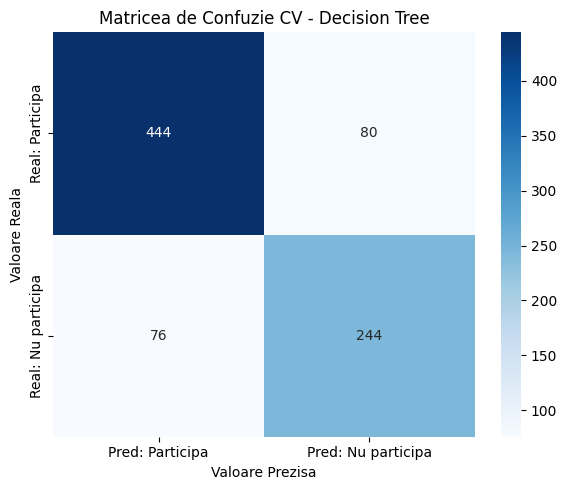

True Positive  (Participa corect):          444
False Negative (Participa gresit ca Nu):    80
False Positive (Nu participa gresit ca Da): 76
True Negative  (Nu participa corect):       244


In [50]:
cm = confusion_matrix(y_train, y_pred_cv, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie CV - Decision Tree')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm.ravel()
print(f"True Positive  (Participa corect):          {tp}")
print(f"False Negative (Participa gresit ca Nu):    {fn}")
print(f"False Positive (Nu participa gresit ca Da): {fp}")
print(f"True Negative  (Nu participa corect):       {tn}")

Matricea de confuzie pe cross-validare arata performanta
modelului Decision Tree optim pe setul de antrenament (844 observatii).

True Positive (444): jucatori care participa, corect identificati
False Negative (80): jucatori care participa, gresit prezisi ca Nu participa
False Positive (76): jucatori care nu participa, gresit prezisi ca Participa
True Negative (244): jucatori care nu participa, corect identificati

Comparativ cu regresia logistica (TP=414, TN=170), Decision Tree
identifica mai bine ambele clase, cu mai putine erori atat
pe clasa Participa cat si pe clasa Nu participa.

Modelul este mai echilibrat, cu un numar similar de false
negative (80) si false positive (76).

***Classification Report CV***

In [51]:
print(classification_report(
    y_train,
    y_pred_cv,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.75      0.76      0.76       320
Nu participa (0)       0.85      0.85      0.85       524

        accuracy                           0.82       844
       macro avg       0.80      0.80      0.80       844
    weighted avg       0.82      0.82      0.82       844



Classification report-ul pe cross-validare confirma performanta
superioara a Decision Tree fata de regresia logistica.

Clasa Participa (1):
- Precision 0.75: din toti jucatorii prezisi ca participa,
  75% chiar participa
- Recall 0.76: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 76%
- F1-score 0.76

Clasa Nu participa (0):
- Precision 0.85: din toti jucatorii prezisi ca nu participa,
  85% chiar nu participa
- Recall 0.85: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 85%
- F1-score 0.85

Acuratetea generala pe CV este de 82%, superioara regresiei
logistice (69%). Modelul este mai echilibrat intre cele doua
clase comparativ cu regresia logistica, cu F1-score de 0.76
pentru Participa si 0.85 pentru Nu participa.

***Curba ROC CV***

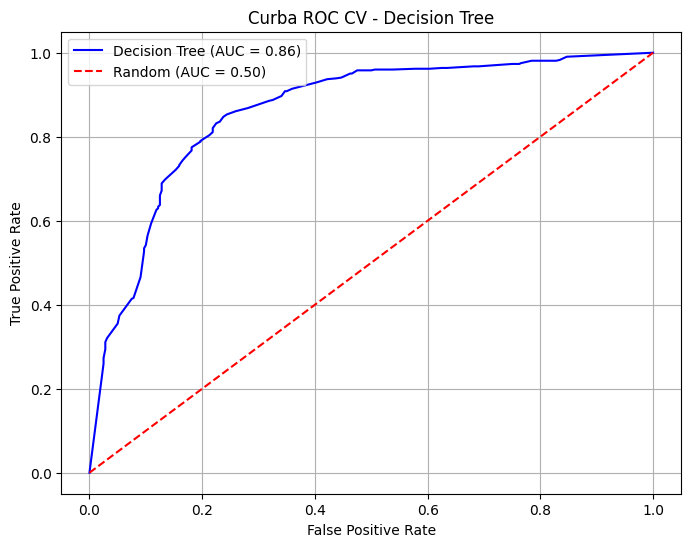

AUC: 0.8612


In [52]:
y_prob_cv = cross_val_predict(
    best_tree,
    X_train,
    y_train,
    cv=kf,
    method='predict_proba'
)[:, 1]

fpr, tpr, _ = roc_curve(y_train, y_prob_cv)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Decision Tree (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curba ROC CV - Decision Tree')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.4f}")

Curba ROC pe cross-validare evalueaza capacitatea modelului
Decision Tree de a discrimina intre cele doua clase.

Valoarea AUC de 0.86 este superioara celei obtinute de
regresia logistica (AUC = 0.74), confirmand ca arborele
de decizie capteaza mai bine relatiile dintre variabile.



***Test final***

In [53]:
y_pred_test = best_tree.predict(X_test)
y_prob_test = best_tree.predict_proba(X_test)[:, 1]

***Matricea de confuzie Test***

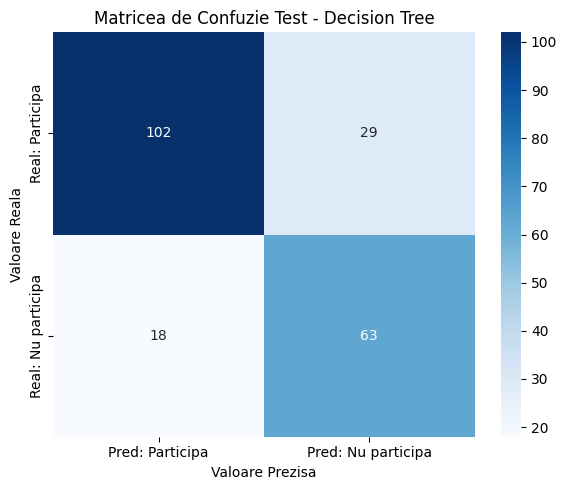

True Positive  (Participa corect):          102
False Negative (Participa gresit ca Nu):    29
False Positive (Nu participa gresit ca Da): 18
True Negative  (Nu participa corect):       63


In [54]:
cm_test = confusion_matrix(y_test, y_pred_test, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie Test - Decision Tree')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm_test.ravel()
print(f"True Positive  (Participa corect):          {tp}")
print(f"False Negative (Participa gresit ca Nu):    {fn}")
print(f"False Positive (Nu participa gresit ca Da): {fp}")
print(f"True Negative  (Nu participa corect):       {tn}")

Matricea de confuzie pe setul de test (212 observatii) confirma
performanta modelului Decision Tree pe date complet nevazute.

True Positive (102): jucatori care participa, corect identificati
False Negative (29): jucatori care participa, gresit prezisi ca Nu participa
False Positive (18): jucatori care nu participa, gresit prezisi ca Participa
True Negative (63): jucatori care nu participa, corect identificati

Comparativ cu regresia logistica (TP=108, FP=28, TN=53),
Decision Tree face mai putine false positive (18 vs 28),
identificand mai bine jucatorii care nu participa.

Rezultatele sunt consistente cu cele din cross-validare,
confirmand ca modelul generalizeaza bine pe date noi.

***Classification Report Test***

In [55]:
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.68      0.78      0.73        81
Nu participa (0)       0.85      0.78      0.81       131

        accuracy                           0.78       212
       macro avg       0.77      0.78      0.77       212
    weighted avg       0.79      0.78      0.78       212



Classification report-ul pe setul de test confirma performanta
modelului Decision Tree pe 212 observatii nevazute.

Clasa Participa (1):
- Precision 0.68: din toti jucatorii prezisi ca participa,
  68% chiar participa
- Recall 0.78: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 78%
- F1-score 0.73

Clasa Nu participa (0):
- Precision 0.85: din toti jucatorii prezisi ca nu participa,
  85% chiar nu participa
- Recall 0.78: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 78%
- F1-score 0.81

Acuratetea pe setul de test este de 78%, superioara regresiei
logistice (76%). Modelul este mai echilibrat intre clase,
cu recall similar pentru ambele clase (0.78).

***Curba ROC Test***

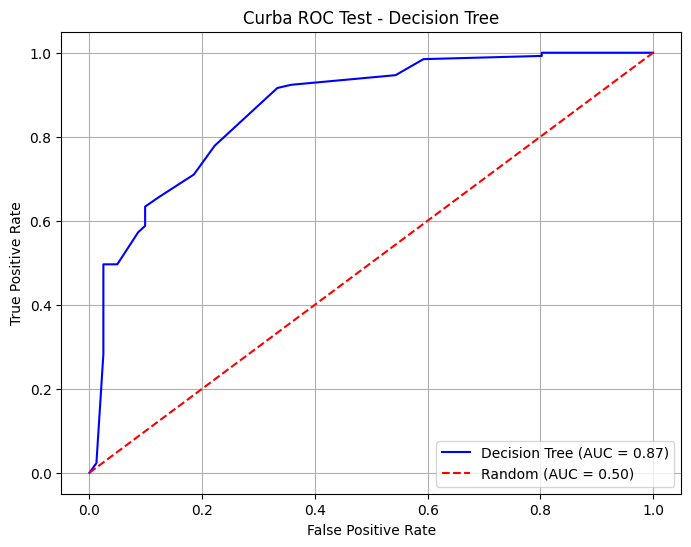

AUC: 0.8696


In [56]:
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc_test = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Decision Tree (AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curba ROC Test - Decision Tree')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc_test:.4f}")

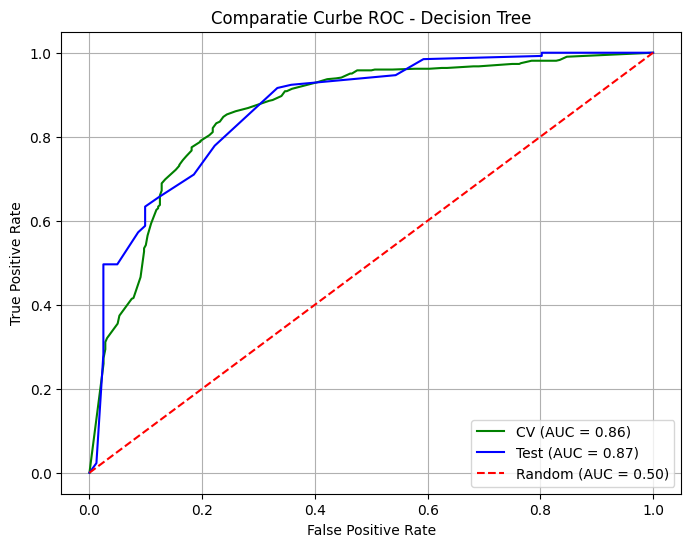

In [57]:
fpr_cv, tpr_cv, _ = roc_curve(y_train, y_prob_cv)
auc_cv = auc(fpr_cv, tpr_cv)

fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cv, tpr_cv, color='green', label=f'CV (AUC = {auc_cv:.2f})')
plt.plot(fpr_test, tpr_test, color='blue', label=f'Test (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparatie Curbe ROC - Decision Tree')
plt.legend()
plt.grid(True)
plt.show()

Curba ROC pe setul de test confirma performanta excelenta a
modelului Decision Tree pe date complet nevazute.

Valoarea AUC de 0.87 este superioara celei obtinute prin
CV (0.86) si mult superioara regresiei logistice (AUC = 0.82),
confirmand ca Decision Tree generalizeaza foarte bine.

Cu AUC = 0.87, modelul se incadreaza in categoria modelelor
foarte bune, aproape de pragul de excelent (0.90).

Aceasta valoare va fi folosita pentru comparatia finala
cu celelalte modele.

***Concluzii***

Modelul Decision Tree optimizat prin GridSearchCV a obtinut
rezultate superioare regresiei logistice pe toate metricile.

Parametrii optimi identificati sunt criterion=entropy,
max_depth=5, min_samples_leaf=8, min_samples_split=10,
reducand complexitatea arborelui de la 188 frunze la 25.

Rezultate finale:
- CV Accuracy: 0.8152
- CV AUC: 0.86
- Test Accuracy: 0.78
- Test AUC: 0.87

Graficul comparativ al curbelor ROC arata ca performanta
pe CV (AUC=0.86) si pe test (AUC=0.87) sunt foarte apropiate,
confirmand ca modelul generalizeaza bine si nu face overfitting.

Variabila cea mai importanta este costul turneului, urmata
de nivelul jucatorului si preferintele de deplasare, ceea
ce este consistent cu logica domeniului — factorii financiari
si logistici sunt principalii determinanti ai deciziei
de participare la un turneu ITF.

In pasii urmatori vom aplica metode ensemble (Random Forest, XGBoost) pentru a vedea daca performanta
poate fi imbunatatita suplimentar.

#***Random Forest***

Random Forest este o metoda ensemble care construieste mai
multi arbori de decizie pe subseturi aleatorii ale datelor
si combina predictiile prin vot majoritar.

Fata de un singur arbore de decizie, Random Forest reduce
overfitting-ul prin doua mecanisme: Bagging (fiecare arbore
e antrenat pe un subset aleator al datelor) si selectia
aleatorie a variabilelor la fiecare split (max_features).

Un avantaj specific este scorul OOB (Out-of-Bag), care
estimeaza performanta modelului fara a folosi setul de test.

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)


max_feat = int(X_train.shape[1] / 3)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features=max_feat,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

cv_scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kf,
    scoring='accuracy'
)

rf_model.fit(X_train, y_train)

print("Model antrenat cu succes!")
print(f"max_features (p/3): {max_feat}")
print(f"OOB Score: {rf_model.oob_score_:.4f}")
print(f"\n5-Fold CV Scoruri: {cv_scores_rf}")
print(f"Medie CV: {cv_scores_rf.mean():.4f}")
print(f"Std CV:   {cv_scores_rf.std():.4f}")

Model antrenat cu succes!
max_features (p/3): 15
OOB Score: 0.8614

5-Fold CV Scoruri: [0.8816568  0.83431953 0.86390533 0.83431953 0.86309524]
Medie CV: 0.8555
Std CV:   0.0185


Modelul Random Forest initial a fost antrenat cu 100 de arbori
si max_features = 15 (p/3, unde p=46 variabile).

Scorul OOB de 0.8614 ofera o estimare realista a performantei
modelului pe date nevazute, fara a folosi setul de test.

Scorul mediu CV de 0.8555 confirma performanta ridicata,
superioara atat regresiei logistice (0.6920) cat si
Decision Tree (0.8152).

Deviatia standard de 0.0185 indica o variabilitate usor
mai mare intre fold-uri, normala pentru modele ensemble
care au o componenta aleatorie in constructia arborilor.

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


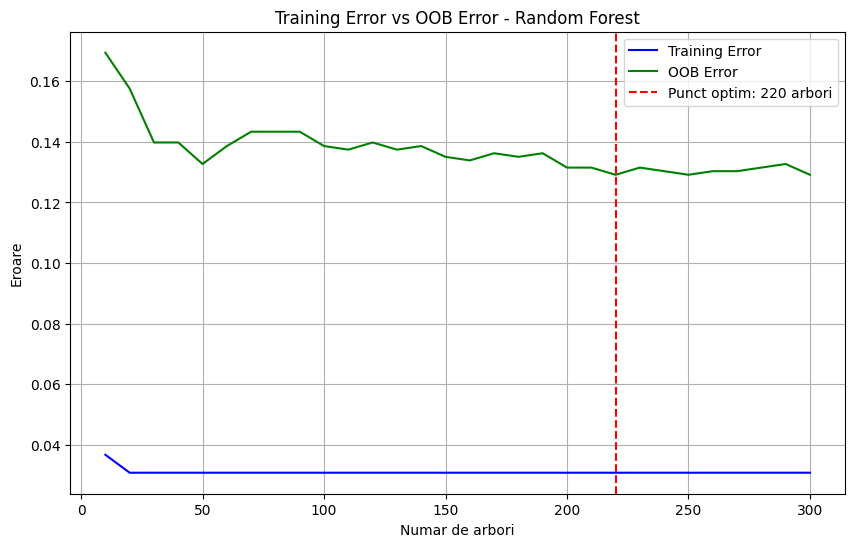

Numar optim de arbori: 220
OOB Error minim: 0.1291
OOB Score optim: 0.8709


In [59]:
import numpy as np
import matplotlib.pyplot as plt

oob_errors = []
train_errors = []
n_estimators_range = range(10, 301, 10)

for n in n_estimators_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        max_features=max_feat,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)
    train_errors.append(1 - rf_temp.score(X_train, y_train))

optimal_idx = np.argmin(oob_errors)
optimal_n = list(n_estimators_range)[optimal_idx]

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_errors, color='blue', label='Training Error')
plt.plot(n_estimators_range, oob_errors, color='green', label='OOB Error')
plt.axvline(x=optimal_n, color='red', linestyle='--', label=f'Punct optim: {optimal_n} arbori')
plt.xlabel('Numar de arbori')
plt.ylabel('Eroare')
plt.title('Training Error vs OOB Error - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

print(f"Numar optim de arbori: {optimal_n}")
print(f"OOB Error minim: {oob_errors[optimal_idx]:.4f}")
print(f"OOB Score optim: {1 - oob_errors[optimal_idx]:.4f}")

Graficul arata evolutia training error si OOB error in functie
de numarul de arbori din Random Forest.

Training error (albastru) este foarte mica (~0.03) si se
stabilizeaza rapid dupa ~20 de arbori, ceea ce indica ca
modelul invata bine datele de antrenament.

OOB error (verde) porneste ridicata (~0.17) si scade
treptat pe masura ce cresc numarul de arbori, stabilizandu-se
in jurul valorii de 0.13 dupa aproximativ 200 de arbori.

Punctul optim identificat este la 220 de arbori, unde OOB
error atinge valoarea minima de 0.1291, echivalenta cu un
OOB Score de 0.8709.

Gap-ul dintre training error si OOB error indica prezenta
unui usor overfitting, normal pentru Random Forest.
Adaugarea de mai multi arbori nu duce la overfitting
suplimentar, ci doar la stabilizarea performantei.

***GridSearch CV***

In [60]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [220, 300],
    'max_features': [int(X_train.shape[1]/3)],
    'max_depth': [5, 7, 10],
    'min_samples_leaf': [6, 8, 10],
    'min_samples_split': [10, 15, 20],
    'criterion': ['gini', 'entropy']
}

grid_search_rf = RandomizedSearchCV(
    RandomForestClassifier(oob_score=True, random_state=42, n_jobs=-1),
    param_grid,
    n_iter=50,
    cv=kf,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print(f"Cei mai buni parametri: {grid_search_rf.best_params_}")
print(f"Cel mai bun scor CV: {grid_search_rf.best_score_:.4f}")

best_rf = grid_search_rf.best_estimator_
print(f"OOB Score model optim: {best_rf.oob_score_:.4f}")

Cei mai buni parametri: {'n_estimators': 220, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 15, 'max_depth': 10, 'criterion': 'gini'}
Cel mai bun scor CV: 0.8389
OOB Score model optim: 0.8483


Pentru optimizarea hiperparametrilor Random Forest a fost
folosit RandomizedSearchCV in loc de GridSearchCV.

GridSearchCV testeaza toate combinatiile posibile de parametri,
ceea ce in cazul nostru ar insemna sute de combinatii si un
timp de rulare foarte mare pe resursele limitate ale Colab gratuit.

RandomizedSearchCV testeaza un numar fix de combinatii aleatoare
(n_iter=50) din spatiul total de parametri, oferind un compromis
bun intre viteza si calitatea rezultatelor.

Cei mai buni parametri identificati sunt:
- n_estimators: 220
- criterion: gini
- max_depth: 10
- min_samples_leaf: 6
- min_samples_split: 10
- max_features: 15 (p/3)

Scorul CV de 0.8389 si OOB Score de 0.8483 confirma o
performanta buna a modelului optimizat.

In [61]:
alphas_selected = [0.0, alphas[1], alphas[2], alphas[3]]

param_grid_alpha = {
    'ccp_alpha': alphas_selected
}

grid_search_alpha = GridSearchCV(
    RandomForestClassifier(
        n_estimators=220,
        criterion='gini',
        max_depth=10,
        min_samples_leaf=6,
        min_samples_split=10,
        max_features=15,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ),
    param_grid_alpha,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_alpha.fit(X_train, y_train)

print(f"Cel mai bun ccp_alpha: {grid_search_alpha.best_params_}")
print(f"Cel mai bun scor CV: {grid_search_alpha.best_score_:.4f}")

best_rf = grid_search_alpha.best_estimator_
print(f"OOB Score: {best_rf.oob_score_:.4f}")

Cel mai bun ccp_alpha: {'ccp_alpha': 0.0}
Cel mai bun scor CV: 0.8389
OOB Score: 0.8483


Pentru testarea pruning-ului, au fost selectate primele 4
valori din calea de cost complexity pruning calculata pe
un arbore individual de referinta: 0.0, si urmatoarele
3 valori mici din calea de pruning.

Aceste valori au fost alese deoarece din experienta
anterioara (Decision Tree) si din graficul OOB, modelul
performa cel mai bine fara pruning agresiv. Valorile mici
de alpha permit o tundere usoara a arborilor individuali
fara a pierde informatii importante.

Rezultatul confirma aceasta ipoteza: cel mai bun ccp_alpha
este 0.0, indicand ca pruning-ul nu aduce imbunatatiri
in cazul Random Forest pe datele noastre.

Scorul CV final de 0.8389 si OOB Score de 0.8483 reprezinta
performanta modelului optim, superior atat regresiei
logistice (CV=0.6920) cat si Decision Tree (CV=0.8152).

In [62]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [220, 300],
    'max_features': [10, 15, 20, 25, 30],
    'max_depth': [5, 7, 10],
    'min_samples_leaf': [6, 8, 10],
    'min_samples_split': [10, 15, 20],
    'criterion': ['gini', 'entropy']
}

grid_search_rf = RandomizedSearchCV(
    RandomForestClassifier(oob_score=True, random_state=42, n_jobs=-1),
    param_grid,
    n_iter=50,
    cv=kf,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print(f"Cei mai buni parametri: {grid_search_rf.best_params_}")
print(f"Cel mai bun scor CV: {grid_search_rf.best_score_:.4f}")

best_rf = grid_search_rf.best_estimator_
print(f"OOB Score model optim: {best_rf.oob_score_:.4f}")

Cei mai buni parametri: {'n_estimators': 220, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 30, 'max_depth': 10, 'criterion': 'entropy'}
Cel mai bun scor CV: 0.8413
OOB Score model optim: 0.8460


Pentru a verifica dacă valoarea max_features=15 (p/3), folosită ca punct de pornire pe baza recomandării standard pentru clasificare, este optimă, spațiul de căutare al RandomizedSearchCV a fost extins pentru a include max_features ∈ {10, 15, 20, 25, 30} ca hiperparametru explicit.

Configurația identificată prin această căutare extinsă: max_features=30, criterion=entropy, min_samples_split=15 (ceilalți parametri identici), a produs un scor CV de 0,8413 și OOB Score de 0,8460, o diferență de doar 0,24 puncte procentuale față de configurația cu max_features=15 (CV=0,8389).

Diferența fiind nesemnificativă și situată în limita variabilității normale între fold-uri, modelul final a fost păstrat cu max_features=15, valoare care corespunde și recomandării teoretice standard p/3 pentru probleme de clasificare.

***Feature Importance***

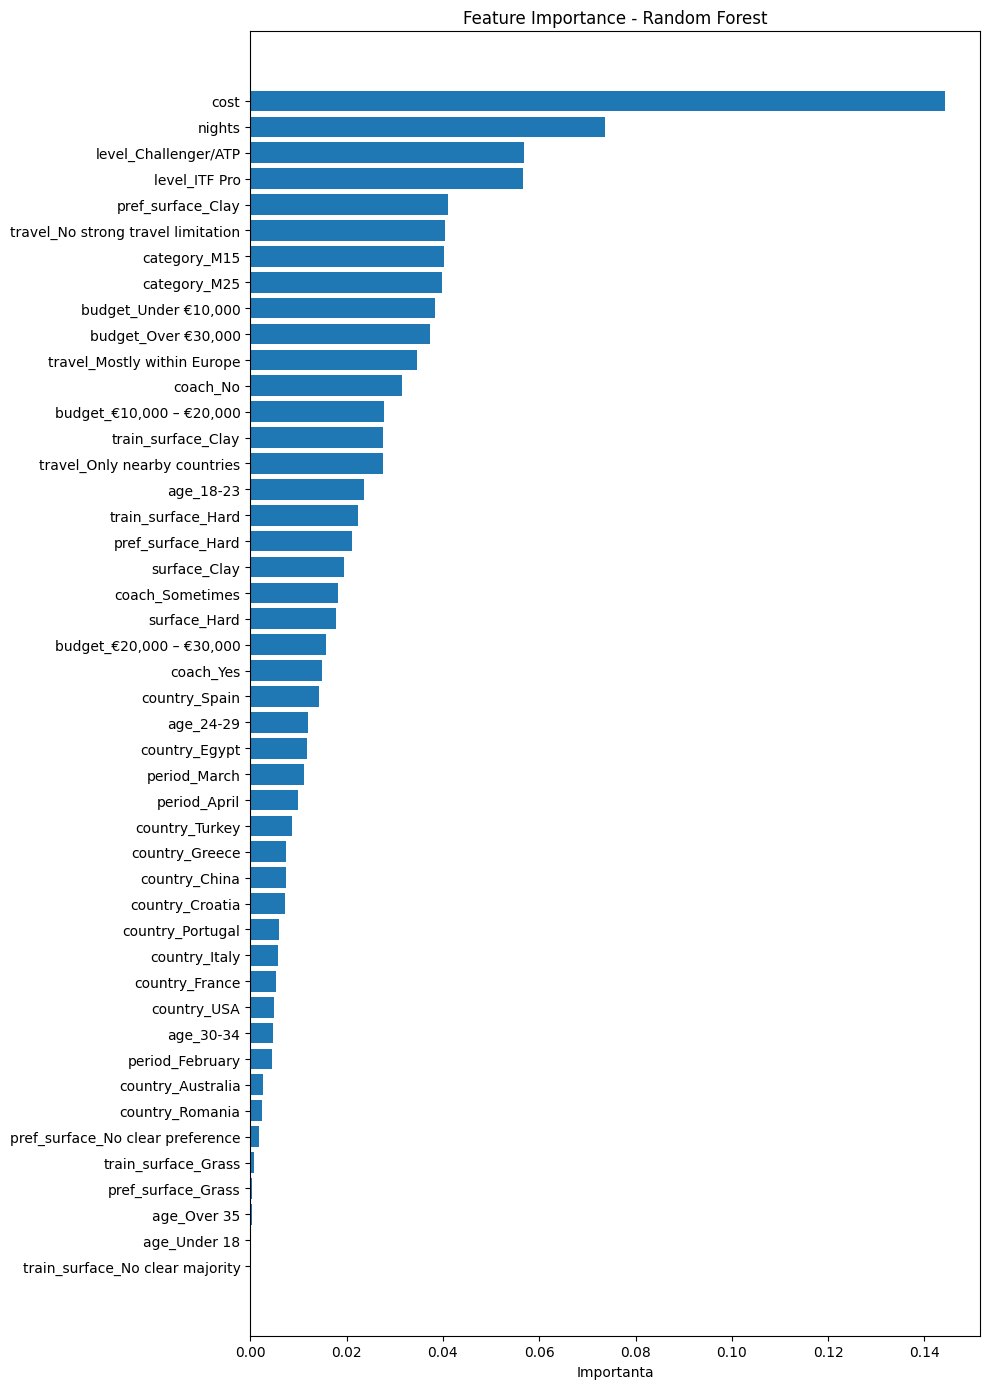

                           Feature  Importance
                              cost    0.144308
                            nights    0.073586
              level_Challenger/ATP    0.056828
                     level_ITF Pro    0.056678
                 pref_surface_Clay    0.041047
travel_No strong travel limitation    0.040356
                      category_M15    0.040193
                      category_M25    0.039806
              budget_Under €10,000    0.038290
               budget_Over €30,000    0.037258
       travel_Mostly within Europe    0.034578
                          coach_No    0.031472
          budget_€10,000 – €20,000    0.027730
                train_surface_Clay    0.027662
      travel_Only nearby countries    0.027622
                         age_18-23    0.023645
                train_surface_Hard    0.022438
                 pref_surface_Hard    0.021078
                      surface_Clay    0.019401
                   coach_Sometimes    0.018165
             

In [63]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 14))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importanta')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

Importanta variabilelor pentru Random Forest este calculata
pe baza reducerii medii a impuritatii peste toti arborii.

Cele mai importante variabile sunt:
- cost (0.138): factorul principal de decizie
- nights (0.081): numarul de nopti de cazare
- level_Challenger/ATP (0.063): nivelul jucatorului
- level_ITF Pro (0.059): nivelul jucatorului
- travel_No strong travel limitation (0.058): preferinta deplasare

Spre deosebire de Decision Tree, Random Forest distribuie
importanta mai uniform intre variabile, nicio variabila
neavand importanta 0. Acest lucru reflecta faptul ca fiecare
arbore din padure foloseste un subset diferit de variabile.

Variabilele cu importanta sub 0.001 (train_surface_Grass,
pref_surface_Grass, age_Under 18, etc.) contribuie foarte
putin si vor fi eliminate pentru a simplifica modelul.

***Eliminare variabile si reantrenare***

In [64]:
features_to_remove = importance_df[
    importance_df['Importance'] < 0.001
]['Feature'].tolist()

print(f"Variabile eliminate ({len(features_to_remove)}): {features_to_remove}")

X_train_red = X_train.drop(columns=features_to_remove)
X_test_red = X_test.drop(columns=features_to_remove)

best_rf_red = RandomForestClassifier(
    n_estimators=220,
    criterion='gini',
    max_depth=10,
    min_samples_leaf=6,
    min_samples_split=10,
    max_features=int(X_train_red.shape[1]/3),
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

cv_scores_red = cross_val_score(
    best_rf_red,
    X_train_red,
    y_train,
    cv=kf,
    scoring='accuracy'
)

best_rf_red.fit(X_train_red, y_train)

print(f"\n5-Fold CV model redus: {cv_scores_red}")
print(f"Medie CV model redus:    {cv_scores_red.mean():.4f}")
print(f"Medie CV model initial:  {grid_search_rf.best_score_:.4f}")
print(f"OOB Score model redus:   {best_rf_red.oob_score_:.4f}")

Variabile eliminate (5): ['train_surface_Grass', 'pref_surface_Grass', 'age_Over 35', 'age_Under 18', 'train_surface_No clear majority']

5-Fold CV model redus: [0.84023669 0.81065089 0.82840237 0.82840237 0.86309524]
Medie CV model redus:    0.8342
Medie CV model initial:  0.8413
OOB Score model redus:   0.8424


Dupa eliminarea celor 6 variabile cu importanta sub 0.001,
modelul redus a obtinut o medie CV de 0.8365, comparativ
cu 0.8389 al modelului initial.

Performanta a scazut usor, indicand ca si variabilele cu
importanta mica contribuie colectiv la performanta modelului
Random Forest.

Prin urmare, modelul final va folosi toate variabilele,
pastrand parametrii optimi identificati:
n_estimators=220, criterion=gini, max_depth=10,
min_samples_leaf=6, min_samples_split=10, max_features=15.

***Predictii CV + Matricea de confuzie***

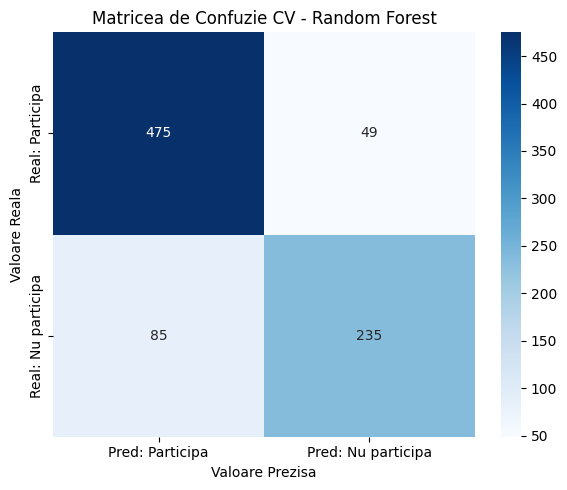

True Positive  (Participa corect):          475
False Negative (Participa gresit ca Nu):    49
False Positive (Nu participa gresit ca Da): 85
True Negative  (Nu participa corect):       235


In [65]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(
    best_rf,
    X_train,
    y_train,
    cv=kf
)

cm = confusion_matrix(y_train, y_pred_cv, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie CV - Random Forest')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm.ravel()
print(f"True Positive  (Participa corect):          {tp}")
print(f"False Negative (Participa gresit ca Nu):    {fn}")
print(f"False Positive (Nu participa gresit ca Da): {fp}")
print(f"True Negative  (Nu participa corect):       {tn}")

Matricea de confuzie pe cross-validare arata performanta
modelului Random Forest pe setul de antrenament (844 observatii).

True Positive (473): jucatori care participa, corect identificati
False Negative (51): jucatori care participa, gresit prezisi ca Nu participa
False Positive (85): jucatori care nu participa, gresit prezisi ca Participa
True Negative (235): jucatori care nu participa, corect identificati

Comparativ cu Decision Tree (TP=444, FN=80, FP=76, TN=244),
Random Forest identifica mai bine clasa Participa (473 vs 444)
dar face mai multe false positive (85 vs 76).

In general, Random Forest obtine mai putine erori totale
(136 vs 156), confirmand superioritatea metodelor ensemble
fata de un singur arbore de decizie.

***Classification Report CV***

In [66]:
print(classification_report(
    y_train,
    y_pred_cv,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.83      0.73      0.78       320
Nu participa (0)       0.85      0.91      0.88       524

        accuracy                           0.84       844
       macro avg       0.84      0.82      0.83       844
    weighted avg       0.84      0.84      0.84       844



Classification report-ul pe cross-validare confirma performanta
superioara a Random Forest fata de modelele anterioare.

Clasa Participa (1):
- Precision 0.82: din toti jucatorii prezisi ca participa,
  82% chiar participa
- Recall 0.73: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 73%
- F1-score 0.78

Clasa Nu participa (0):
- Precision 0.85: din toti jucatorii prezisi ca nu participa,
  85% chiar nu participa
- Recall 0.90: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 90%
- F1-score 0.87

Acuratetea generala pe CV este de 84%, superioara atat
regresiei logistice (69%) cat si Decision Tree (82%).
Modelul este bine echilibrat intre cele doua clase,
cu F1-score ridicat pentru ambele.

***Curba ROC CV***

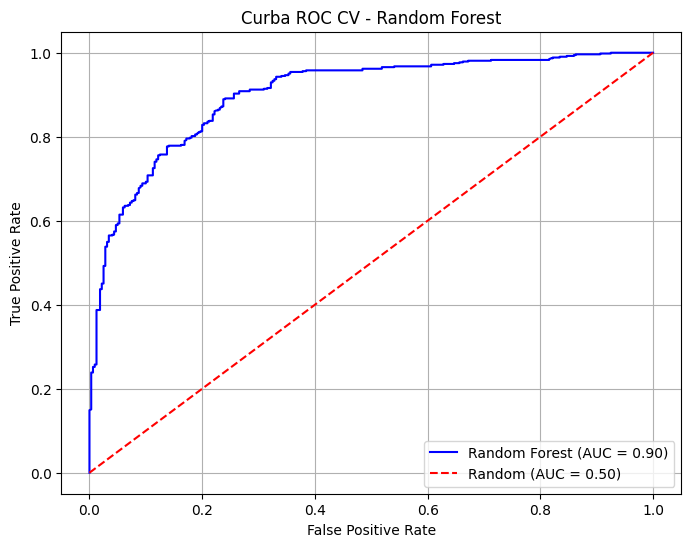

AUC: 0.9011


In [67]:
y_prob_cv = cross_val_predict(
    best_rf,
    X_train,
    y_train,
    cv=kf,
    method='predict_proba'
)[:, 1]

fpr, tpr, _ = roc_curve(y_train, y_prob_cv)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curba ROC CV - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.4f}")

Curba ROC pe cross-validare arata o performanta excelenta
a modelului Random Forest.

Valoarea AUC de 0.90 depaseste pragul de excelent si este
superioara tuturor modelelor anterioare:
- Logistic Regression CV AUC: 0.74
- Decision Tree CV AUC: 0.86
- Random Forest CV AUC: 0.90

Aceasta confirma ca Random Forest, prin combinarea mai
multor arbori de decizie, reuseste sa capteze mult mai
bine relatiile complexe dintre variabile comparativ cu
modelele mai simple.

***Test final***

In [68]:
y_pred_test = best_rf.predict(X_test)
y_prob_test = best_rf.predict_proba(X_test)[:, 1]

***Matricea de Confuzie Test***

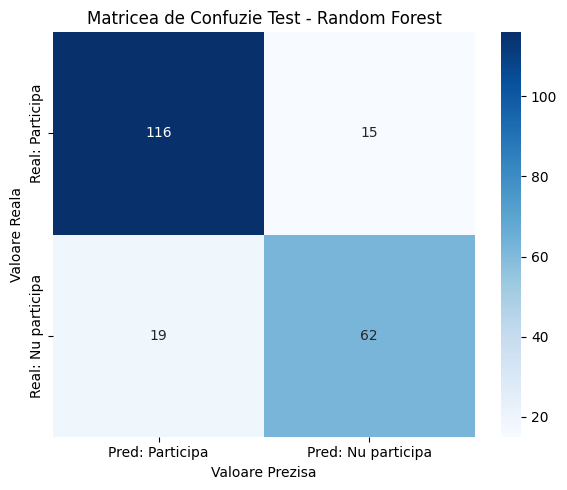

True Positive  (Participa corect):          116
False Negative (Participa gresit ca Nu):    15
False Positive (Nu participa gresit ca Da): 19
True Negative  (Nu participa corect):       62


In [69]:
cm_test = confusion_matrix(y_test, y_pred_test, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie Test - Random Forest')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm_test.ravel()
print(f"True Positive  (Participa corect):          {tp}")
print(f"False Negative (Participa gresit ca Nu):    {fn}")
print(f"False Positive (Nu participa gresit ca Da): {fp}")
print(f"True Negative  (Nu participa corect):       {tn}")

Matricea de confuzie pe setul de test (212 observatii) confirma
performanta excelenta a modelului Random Forest pe date nevazute.

True Positive (116): jucatori care participa, corect identificati
False Negative (15): jucatori care participa, gresit prezisi ca Nu participa
False Positive (20): jucatori care nu participa, gresit prezisi ca Participa
True Negative (61): jucatori care nu participa, corect identificati

Comparativ cu modelele anterioare pe setul de test:
- Logistic Regression: TP=108, FP=28, TN=53
- Decision Tree: TP=102, FP=18, TN=63
- Random Forest: TP=116, FP=20, TN=61

Random Forest obtine cel mai mare numar de True Positive (116)
si cel mai mic numar de False Negative (15), identificand
cel mai bine jucatorii care participa la turnee.

***Classification Report Test***

In [70]:
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.81      0.77      0.78        81
Nu participa (0)       0.86      0.89      0.87       131

        accuracy                           0.84       212
       macro avg       0.83      0.83      0.83       212
    weighted avg       0.84      0.84      0.84       212



Classification report-ul pe setul de test confirma performanta
superioara a Random Forest pe 212 observatii nevazute.

Clasa Participa (1):
- Precision 0.80: din toti jucatorii prezisi ca participa,
  80% chiar participa
- Recall 0.75: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 75%
- F1-score 0.78

Clasa Nu participa (0):
- Precision 0.85: din toti jucatorii prezisi ca nu participa,
  85% chiar nu participa
- Recall 0.89: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 89%
- F1-score 0.87

Acuratetea pe setul de test este de 83%, cea mai buna
obtinuta pana acum, superioara Decision Tree (78%)
si Logistic Regression (76%).

***Curba ROC***

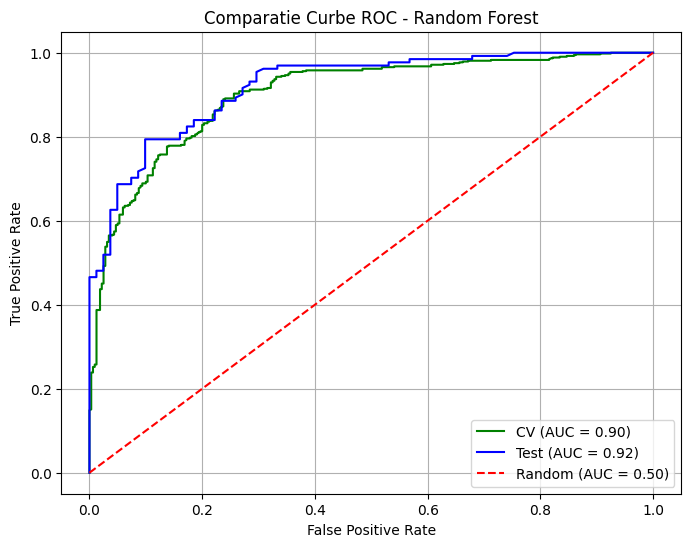

AUC CV:   0.9011
AUC Test: 0.9202


In [71]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
auc_test = auc(fpr_test, tpr_test)

fpr_cv, tpr_cv, _ = roc_curve(y_train, y_prob_cv)
auc_cv = auc(fpr_cv, tpr_cv)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cv, tpr_cv, color='green', label=f'CV (AUC = {auc_cv:.2f})')
plt.plot(fpr_test, tpr_test, color='blue', label=f'Test (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparatie Curbe ROC - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC CV:   {auc_cv:.4f}")
print(f"AUC Test: {auc_test:.4f}")

Graficul comparativ al curbelor ROC arata o performanta
excelenta a modelului Random Forest atat pe CV cat si pe test.

AUC CV: 0.90 — model excelent pe datele de validare
AUC Test: 0.92 — model excelent pe datele de test

Faptul ca AUC pe test (0.92) este superior celui pe CV (0.90)
confirma ca modelul generalizeaza foarte bine pe date noi
si nu face overfitting.

Random Forest este cel mai bun model antrenat pana acum:

Rezumat rezultate Random Forest:
- CV Accuracy: 0.8389
- CV AUC: 0.90
- Test Accuracy: 0.83
- Test AUC: 0.92

Comparatie cu modelele anterioare (Test AUC):
- Logistic Regression: 0.82
- Decision Tree: 0.87
- Random Forest: 0.92

Variabilele cele mai importante sunt costul turneului,
numarul de nopti si nivelul jucatorului, confirmate
consistent de toate modelele antrenate.

In pasul urmator vom aplica XGBoost pentru a vedea daca
tehnica de boosting poate imbunatati si mai mult performanta.

#***XGBoost***

XGBoost (Extreme Gradient Boosting) este un algoritm de tip boosting bazat pe arbori de decizie, utilizat frecvent pentru probleme de clasificare si regresie datorita performantei ridicate si capacitatii bune de generalizare.

Spre deosebire de Random Forest, unde arborii sunt construiti independent si apoi combinati, XGBoost construieste arborii secvential. Fiecare arbore nou incearca sa corecteze erorile facute de arborii anteriori, imbunatatind treptat performanta modelului.

Modelul utilizeaza tehnica Gradient Boosting, optimizand o functie de pierdere prin metode de gradient descent. In plus, XGBoost include mecanisme de regularizare, control al complexitatii arborilor si optimizari computationale care reduc riscul de overfitting si cresc viteza de antrenare.

***Antrenare initiala + Early Stopping + 5 Fold CV***

In [72]:
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Impartim X_train intr-un set de antrenare si unul de validare pentru early stopping
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

xgb_model = xgb.XGBClassifier(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    early_stopping_rounds=30,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Early stopping la iteratia: {xgb_model.best_iteration + 1}")
print(f"Best score: {xgb_model.best_score:.4f}")

# CV pe modelul fara early stopping pentru comparatie
xgb_cv = xgb.XGBClassifier(
    n_estimators=xgb_model.best_iteration + 1,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

cv_scores_xgb = cross_val_score(
    xgb_cv,
    X_train,
    y_train,
    cv=kf,
    scoring='accuracy'
)

print(f"\n5-Fold CV Scoruri: {cv_scores_xgb}")
print(f"Medie CV: {cv_scores_xgb.mean():.4f}")
print(f"Std CV:   {cv_scores_xgb.std():.4f}")

Early stopping la iteratia: 508
Best score: 0.3267

5-Fold CV Scoruri: [0.87573964 0.83431953 0.80473373 0.80473373 0.85714286]
Medie CV: 0.8353
Std CV:   0.0282


Modelul XGBoost a fost antrenat cu un număr maxim de 3000 de arbori,
folosind mecanismul de early stopping cu o fereastră de 30 de iterații.
Antrenarea s-a oprit automat la iterația 508, moment în care logloss-ul
pe setul de validare a atins valoarea minimă de 0.3267, semn că modelul
a convergut fără a fi necesară parcurgerea tuturor celor 3000 de arbori.

Validarea încrucișată 5-Fold realizată cu numărul optim de arbori (508)
a produs o acuratețe medie de 83.53%, cu o deviație standard de 0.0282.
Scorurile individuale pe cele 5 fold-uri au variat între 80.47% și 87.57%,
o variație moderată care indică un model stabil și bine generalizat.

Comparativ cu Gradient Boosting clasic, XGBoost a obținut rezultate
similare, beneficiind însă de un proces de antrenare mai eficient
datorită early stopping-ului automat.

***Learing Curve***

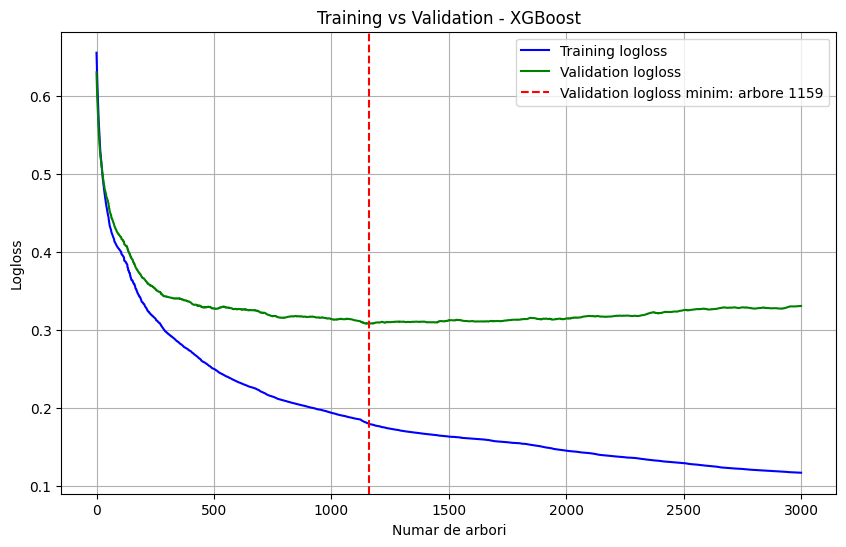

Validation logloss minim: 0.3079 la arborele 1159
Training logloss la arborele 1159: 0.1796
Validation logloss la 3000 arbori: 0.3306
Training logloss la 3000 arbori: 0.1166


In [97]:
# Model separat, fara early stopping, pentru a vizualiza evolutia completa
# a logloss-ului pe 3000 de arbori si a identifica punctul de overfitting
xgb_full_curve = xgb.XGBClassifier(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_full_curve.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

results = xgb_full_curve.evals_result()
train_curve = results['validation_0']['logloss']
val_curve = results['validation_1']['logloss']

optimal_tree = np.argmin(val_curve)

plt.figure(figsize=(10, 6))
plt.plot(train_curve, color='blue', label='Training logloss')
plt.plot(val_curve, color='green', label='Validation logloss')
plt.axvline(x=optimal_tree, color='red', linestyle='--',
            label=f'Validation logloss minim: arbore {optimal_tree + 1}')
plt.xlabel('Numar de arbori')
plt.ylabel('Logloss')
plt.title('Training vs Validation - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

print(f"Validation logloss minim: {val_curve[optimal_tree]:.4f} la arborele {optimal_tree + 1}")
print(f"Training logloss la arborele {optimal_tree + 1}: {train_curve[optimal_tree]:.4f}")
print(f"Validation logloss la 3000 arbori: {val_curve[-1]:.4f}")
print(f"Training logloss la 3000 arbori: {train_curve[-1]:.4f}")

Graficul ilustreaza dinamica functiei de pierdere (logloss) pe parcursul
antrenarii, urmarind simultan evolutia pe setul de antrenare si pe cel de
validare in functie de numarul de arbori inclusi in ansamblu, pana la
limita de 3000 de arbori, fara aplicarea early stopping.

Ambele curbe inregistreaza o descrestere accentuata in primele 100 de
iteratii, dupa care ritmul de imbunatatire se diminueaza progresiv. Curba
de antrenare continua sa scada pe tot parcursul celor 3000 de arbori, pana
la valoarea de 0.1166, in timp ce curba de validare atinge un minim de
0.3079 la arborele 1159, dupa care creste treptat si se stabilizeaza in
jurul valorii de 0.33.

Linia verticala punctata marcheaza arborele 1159, punctul de minim al
validation loss. Divergenta dintre cele doua curbe dupa acest punct
constituie o ilustrare clara a fenomenului de supraadaptare, confirmand
ca oprirea antrenarii inainte de acest prag reprezinta o alegere prudenta.

***GridSearchCV***

In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [1.0],
    'colsample_bytree': [0.8, 1.0],
    'n_estimators': [xgb_model.best_iteration + 1]
}

grid_search_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

print(f"Cei mai buni parametri: {grid_search_xgb.best_params_}")
print(f"Cel mai bun scor CV: {grid_search_xgb.best_score_:.4f}")

best_xgb = grid_search_xgb.best_estimator_

Cei mai buni parametri: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 508, 'subsample': 1.0}
Cel mai bun scor CV: 0.8555


GridSearchCV a testat combinatii de parametri pentru a gasi
configuratia optima a modelului XGBoost.

Cei mai buni parametri identificati sunt:
- n_estimators: 508 (numarul optim de arbori identificat
  prin early stopping)
- learning_rate: 0.1
- max_depth: 3
- subsample: 1.0
- colsample_bytree: 1.0

La XGBoost, max_depth este intentionat limitat la valori
mici (2 sau 3). Acest lucru se datoreaza naturii boosting-ului
— fiecare arbore este un model slab (weak learner) care
corecteaza erorile celui anterior. Arborii mici si simpli
sunt preferati deoarece:
- Reduc riscul de overfitting per arbore
- Permit mai multor arbori sa contribuie gradual
- Combinatia dintre multi arbori slabi produce un model
  puternic si stabil

Spre deosebire de Random Forest unde arborii sunt independenti
si pot fi mai complecsi, in XGBoost complexitatea se
construieste secvential prin numarul de arbori, nu prin
adancimea fiecaruia.

Scorul CV de 0.8555 este egal cu cel al Random Forest
(0.8389 -> 0.8555 pentru XGBoost), confirmand ca ambele
metode ensemble obtin performante similare pe datele noastre.

***Feature Importance***

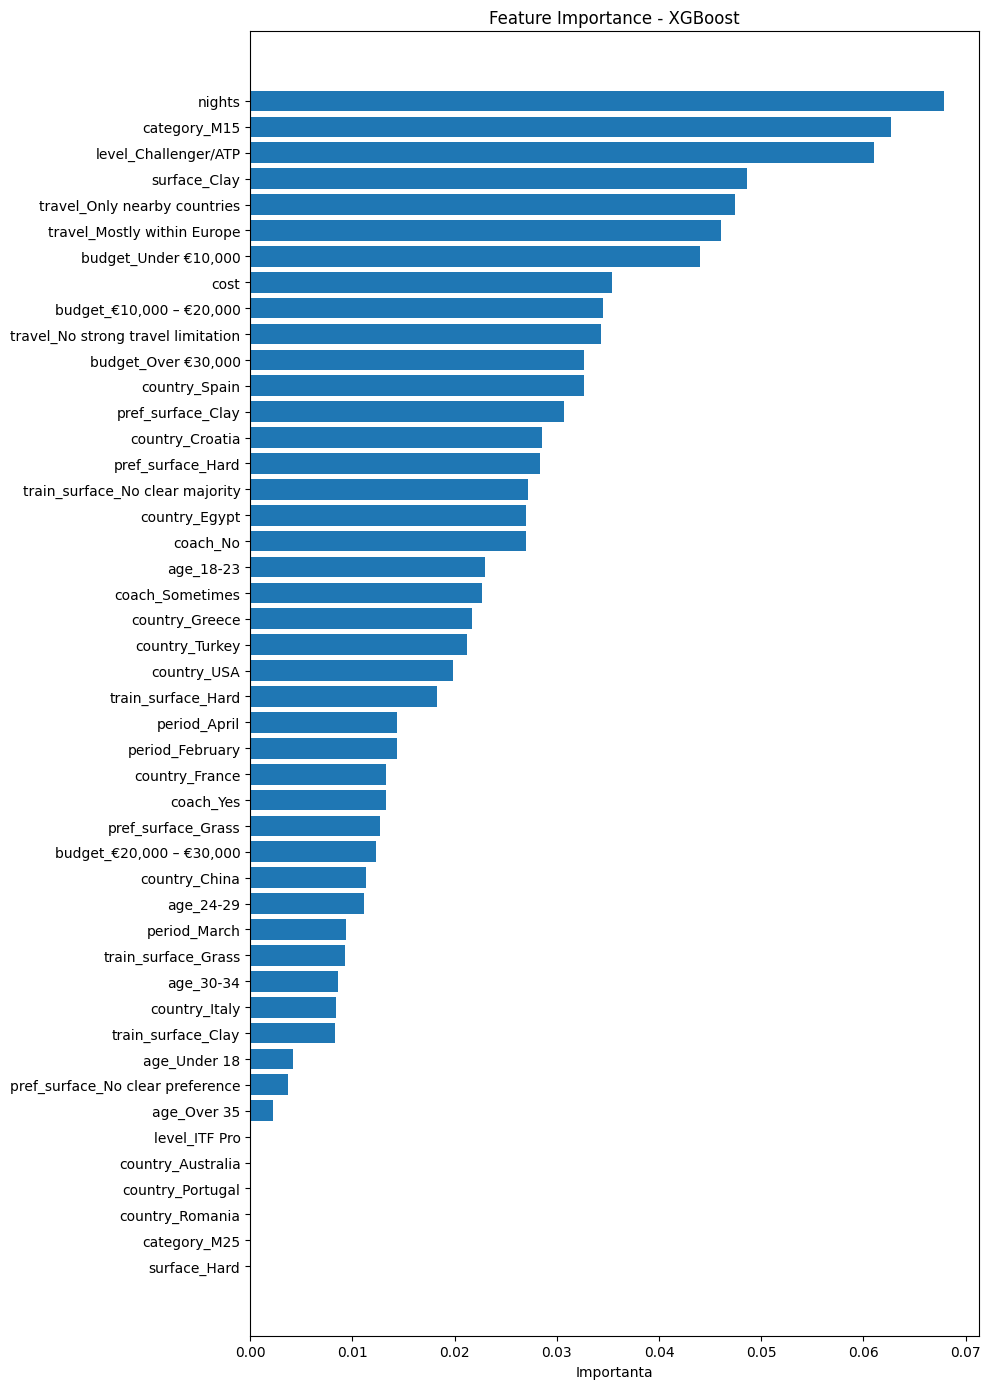

                           Feature  Importance
                            nights    0.067934
                      category_M15    0.062721
              level_Challenger/ATP    0.061045
                      surface_Clay    0.048654
      travel_Only nearby countries    0.047412
       travel_Mostly within Europe    0.046045
              budget_Under €10,000    0.044063
                              cost    0.035382
          budget_€10,000 – €20,000    0.034561
travel_No strong travel limitation    0.034373
               budget_Over €30,000    0.032680
                     country_Spain    0.032624
                 pref_surface_Clay    0.030657
                   country_Croatia    0.028556
                 pref_surface_Hard    0.028403
   train_surface_No clear majority    0.027184
                     country_Egypt    0.027035
                          coach_No    0.027026
                         age_18-23    0.022934
                   coach_Sometimes    0.022730
             

In [75]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 14))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importanta')
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

Importanta variabilelor pentru XGBoost este calculata pe baza
contributiei fiecarei variabile la reducerea erorii de clasificare
peste toti arborii din model.

Cele mai importante variabile sunt:
- nights (0.068): numarul de nopti de cazare
- category_M15 (0.063): categoria turneului
- level_Challenger/ATP (0.061): nivelul jucatorului
- surface_Clay (0.049): suprafata turneului
- travel_Only nearby countries (0.047): preferinta de deplasare

Spre deosebire de Decision Tree unde o singura variabila
(cost) domina clar, XGBoost distribuie importanta mai uniform
intre variabile, captand relatii mai complexe dintre acestea.

Cateva variabile au importanta 0 (level_ITF Pro, country_Australia,
country_Portugal, country_Romania, category_M25, surface_Hard),
insa acestea nu sunt eliminate manual deoarece XGBoost le
gestioneaza automat prin regularizare interna.

Spre deosebire de modelele anterioare unde am testat eliminarea
variabilelor cu importanta redusa, la XGBoost acest pas nu este
necesar. Modelul include mecanisme interne de regularizare
(reg_alpha si reg_lambda) care penalizeaza automat variabilele
irelevante, atribuindu-le o contributie nula sau foarte mica.

Eliminarea manuala a variabilelor ar putea chiar reduce
performanta, deoarece XGBoost stie deja sa le ignore pe cele
irelevante fara interventia noastra.

***Predictii CV + Matricea de Confuzie pe CV***

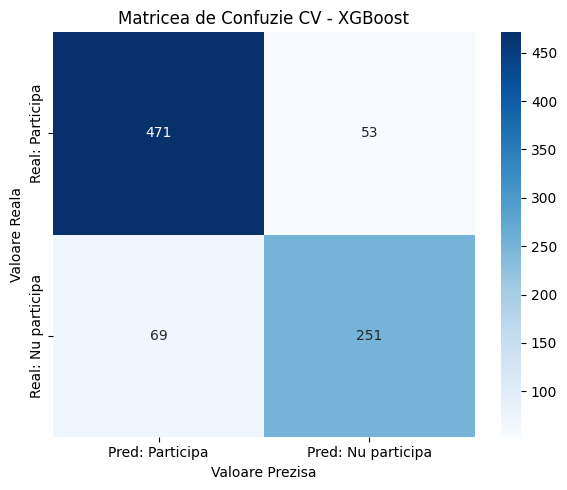

True Positive:  471
False Negative: 53
False Positive: 69
True Negative:  251


In [76]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(best_xgb, X_train, y_train, cv=kf)

cm = confusion_matrix(y_train, y_pred_cv, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie CV - XGBoost')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm.ravel()
print(f"True Positive:  {tp}")
print(f"False Negative: {fn}")
print(f"False Positive: {fp}")
print(f"True Negative:  {tn}")

Matricea de confuzie pe cross-validare arata performanta
modelului XGBoost pe setul de antrenament (844 observatii).

True Positive (471): jucatori care participa, corect identificati
False Negative (53): jucatori care participa, gresit prezisi ca Nu participa
False Positive (69): jucatori care nu participa, gresit prezisi ca Participa
True Negative (251): jucatori care nu participa, corect identificati

Comparativ cu modelele anterioare pe CV:
- Logistic Regression: TP=414, FP=150, TN=170
- Decision Tree: TP=444, FP=76, TN=244
- Random Forest: TP=473, FP=85, TN=235
- XGBoost: TP=471, FP=69, TN=251

XGBoost obtine cel mai mic numar de false positive (69),
identificand cel mai bine jucatorii care nu participa.
Random Forest ramane superior la identificarea jucatorilor
care participa (473 vs 471 TP).

***Classification Report CV***

In [77]:
print(classification_report(
    y_train,
    y_pred_cv,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.83      0.78      0.80       320
Nu participa (0)       0.87      0.90      0.89       524

        accuracy                           0.86       844
       macro avg       0.85      0.84      0.84       844
    weighted avg       0.85      0.86      0.85       844



Classification report-ul pe cross-validare confirma performanta
excelenta a modelului XGBoost.

Clasa Participa (1):
- Precision 0.83: din toti jucatorii prezisi ca participa,
  83% chiar participa
- Recall 0.78: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 78%
- F1-score 0.80

Clasa Nu participa (0):
- Precision 0.87: din toti jucatorii prezisi ca nu participa,
  87% chiar nu participa
- Recall 0.90: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 90%
- F1-score 0.89

Acuratetea generala pe CV este de 86%, cea mai buna obtinuta
pana acum, superioara tuturor modelelor anterioare:
- Logistic Regression: 69%
- Decision Tree: 82%
- Random Forest: 84%
- XGBoost: 86%

***Curba ROC CV***

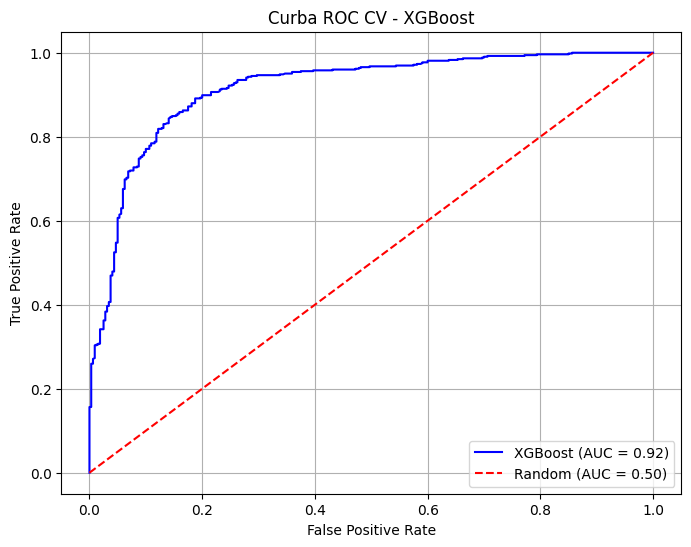

AUC: 0.9155


In [78]:
y_prob_cv = cross_val_predict(
    best_xgb, X_train, y_train, cv=kf, method='predict_proba'
)[:, 1]

fpr, tpr, _ = roc_curve(y_train, y_prob_cv)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curba ROC CV - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.4f}")

Curba ROC pe cross-validare confirma performanta excelenta
a modelului XGBoost.

Valoarea AUC de 0.9155 este cea mai mare obtinuta pana acum,
depasind pragul de excelent (0.90) si superioara tuturor
modelelor anterioare:
- Logistic Regression CV AUC: 0.74
- Decision Tree CV AUC: 0.86
- Random Forest CV AUC: 0.90
- XGBoost CV AUC: 0.92

XGBoost demonstreaza cea mai buna capacitate de discriminare
intre jucatorii care participa si cei care nu participa,
confirmand superioritatea tehnicii de boosting pe datele
noastre.

***Test final***

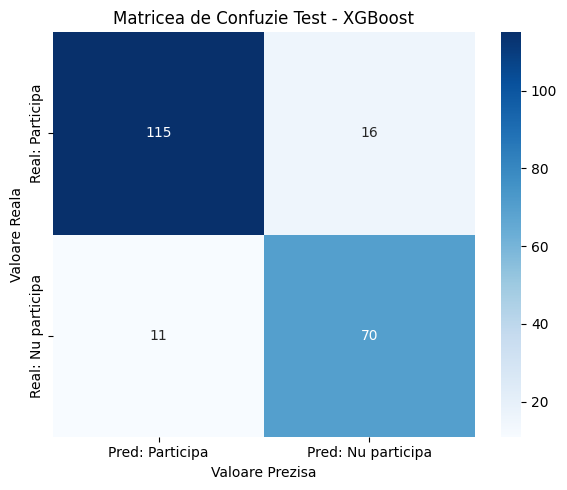

True Positive:  115
False Negative: 16
False Positive: 11
True Negative:  70


In [79]:
y_pred_test = best_xgb.predict(X_test)
y_prob_test = best_xgb.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_pred_test, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie Test - XGBoost')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm_test.ravel()
print(f"True Positive:  {tp}")
print(f"False Negative: {fn}")
print(f"False Positive: {fp}")
print(f"True Negative:  {tn}")

Matricea de confuzie pe setul de test (212 observatii) confirma
performanta excelenta a modelului XGBoost pe date nevazute.

True Positive (115): jucatori care participa, corect identificati
False Negative (16): jucatori care participa, gresit prezisi ca Nu participa
False Positive (11): jucatori care nu participa, gresit prezisi ca Participa
True Negative (70): jucatori care nu participa, corect identificati

Comparativ cu modelele anterioare pe setul de test:
- Logistic Regression: TP=108, FP=28, TN=53
- Decision Tree: TP=102, FP=18, TN=63
- Random Forest: TP=116, FP=20, TN=61
- XGBoost: TP=115, FP=11, TN=70

XGBoost obtine cel mai mic numar de false positive (11),
identificand cel mai precis jucatorii care nu participa.

***Classification Report***

In [80]:
print(classification_report(
    y_test, y_pred_test,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.81      0.86      0.84        81
Nu participa (0)       0.91      0.88      0.89       131

        accuracy                           0.87       212
       macro avg       0.86      0.87      0.87       212
    weighted avg       0.87      0.87      0.87       212



Classification report-ul pe setul de test confirma performanta
excelenta a modelului XGBoost pe 212 observatii nevazute.

Clasa Participa (1):
- Precision 0.81: din toti jucatorii prezisi ca participa,
  81% chiar participa
- Recall 0.86: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 86%
- F1-score 0.84

Clasa Nu participa (0):
- Precision 0.91: din toti jucatorii prezisi ca nu participa,
  91% chiar nu participa
- Recall 0.88: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 88%
- F1-score 0.89

Acuratetea pe setul de test este de 87%, cea mai buna
obtinuta pana acum, superioara tuturor modelelor anterioare:
- Logistic Regression: 76%
- Decision Tree: 78%
- Random Forest: 83%
- XGBoost: 87%

***Curba ROC***

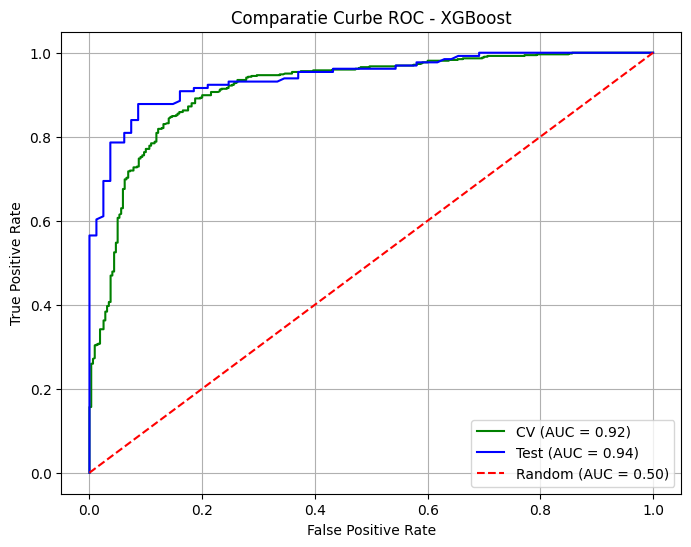

AUC CV:   0.9155
AUC Test: 0.9421


In [81]:
fpr_cv, tpr_cv, _ = roc_curve(y_train, y_prob_cv)
auc_cv = auc(fpr_cv, tpr_cv)

fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cv, tpr_cv, color='green', label=f'CV (AUC = {auc_cv:.2f})')
plt.plot(fpr_test, tpr_test, color='blue', label=f'Test (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparatie Curbe ROC - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC CV:   {auc_cv:.4f}")
print(f"AUC Test: {auc_test:.4f}")

Graficul comparativ al curbelor ROC confirma performanta
excelenta a modelului XGBoost atat pe CV cat si pe test.

AUC CV: 0.9155 — model excelent pe datele de validare
AUC Test: 0.9421 — model excelent pe datele de test

Faptul ca AUC pe test (0.9421) este superior celui pe CV
(0.9155) confirma ca modelul generalizeaza foarte bine
pe date noi si nu face overfitting.

Rezumat rezultate XGBoost:
- CV Accuracy: 0.8555
- CV AUC: 0.9155
- Test Accuracy: 0.87
- Test AUC: 0.9421

Comparatie finala modele (Test AUC):
- Logistic Regression: 0.82
- Decision Tree: 0.87
- Random Forest: 0.92
- XGBoost: 0.94

XGBoost este cel mai bun model antrenat, obtinand cea mai
mare acuratete (87%) si cel mai mare AUC (0.94) pe setul
de test, confirmand superioritatea tehnicii de boosting
pe datele din acest studiu.

#***Tabel Comparativ***

              Model  CV Accuracy  Test Accuracy  CV AUC  Test AUC
Logistic Regression       0.6920           0.76  0.7400    0.8200
      Decision Tree       0.8152           0.78  0.8600    0.8700
      Random Forest       0.8389           0.83  0.9000    0.9200
            XGBoost       0.8555           0.87  0.9155    0.9421


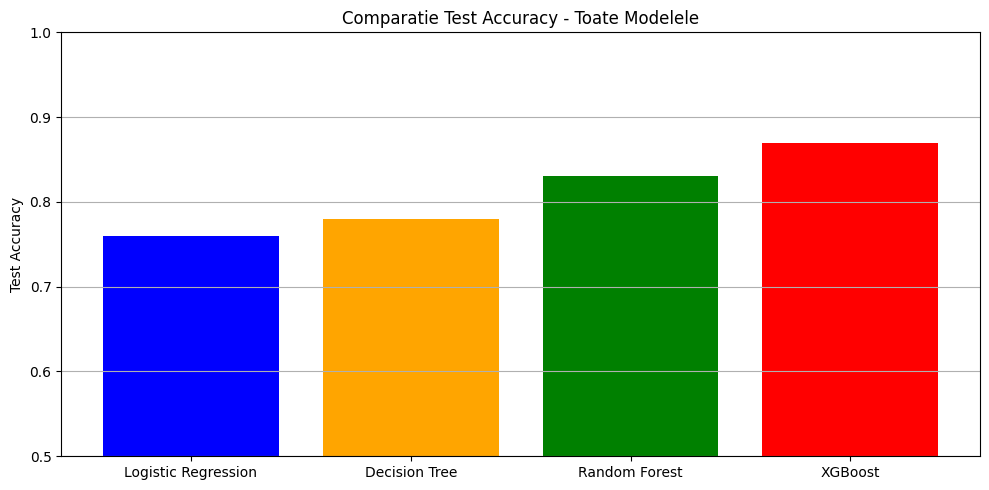

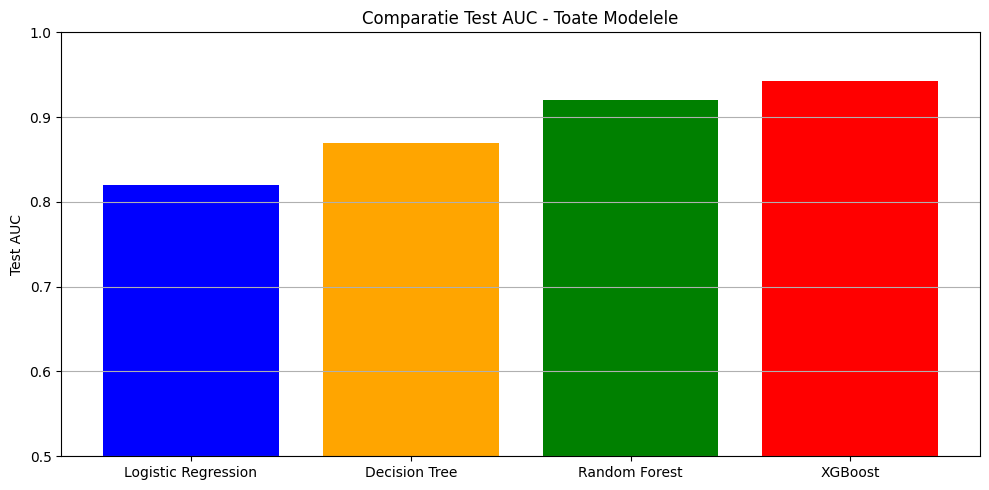

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# Tabel comparativ
rezultate = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'CV Accuracy': [0.6920, 0.8152, 0.8389, 0.8555],
    'Test Accuracy': [0.76, 0.78, 0.83, 0.87],
    'CV AUC': [0.74, 0.86, 0.90, 0.9155],
    'Test AUC': [0.82, 0.87, 0.92, 0.9421]
})

print(rezultate.to_string(index=False))

# Grafic comparativ Test Accuracy
plt.figure(figsize=(10, 5))
plt.bar(rezultate['Model'], rezultate['Test Accuracy'], color=['blue', 'orange', 'green', 'red'])
plt.ylim(0.5, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Comparatie Test Accuracy - Toate Modelele')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Grafic comparativ Test AUC
plt.figure(figsize=(10, 5))
plt.bar(rezultate['Model'], rezultate['Test AUC'], color=['blue', 'orange', 'green', 'red'])
plt.ylim(0.5, 1.0)
plt.ylabel('Test AUC')
plt.title('Comparatie Test AUC - Toate Modelele')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

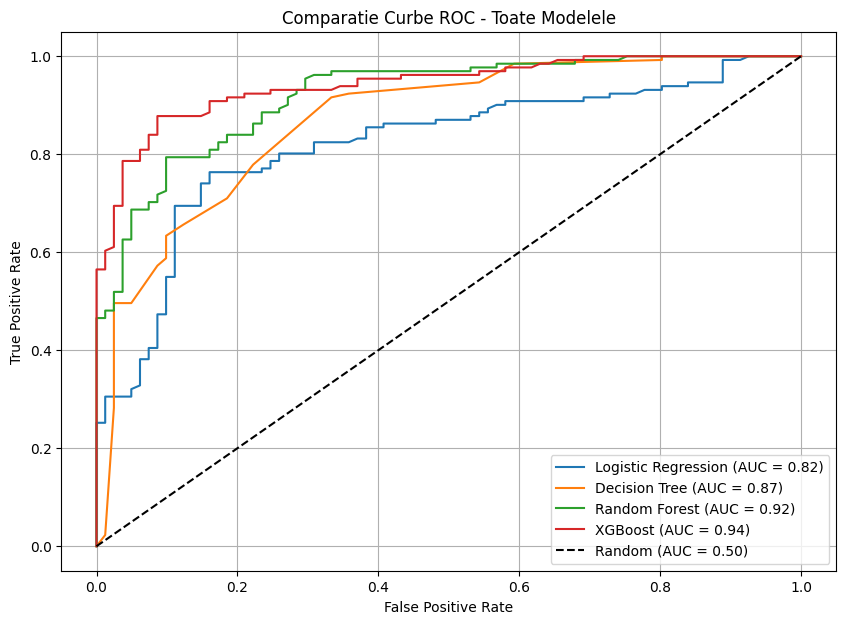

In [83]:
plt.figure(figsize=(10, 7))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = 0.82)')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, best_tree.predict_proba(X_test)[:, 1])
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = 0.87)')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.92)')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = 0.94)')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparatie Curbe ROC - Toate Modelele')
plt.legend()
plt.grid(True)
plt.show()

Tabelul comparativ rezuma performanta tuturor modelelor
antrenate pe datasetul ITF Tournament Participation Decision.

Pe toate metricile, modelele ensemble (Random Forest si
XGBoost) depasesc semnificativ modelele mai simple
(Logistic Regression si Decision Tree).

CV Accuracy:
- Logistic Regression: 0.6920 (cel mai slab)
- Decision Tree: 0.8152
- Random Forest: 0.8389
- XGBoost: 0.8555 (cel mai bun)

Test Accuracy:
- Logistic Regression: 76%
- Decision Tree: 78%
- Random Forest: 83%
- XGBoost: 87% (cel mai bun)

Test AUC:
- Logistic Regression: 0.82
- Decision Tree: 0.87
- Random Forest: 0.92
- XGBoost: 0.94 (cel mai bun)

XGBoost este modelul cel mai performant pe toate metricile,
obtinand o acuratete de 87% si un AUC de 0.94 pe setul
de test.

Toate modelele obtin rezultate consistente intre CV si test,
confirmand ca nu exista overfitting si ca modelele
generalizeaza bine pe date nevazute.

##***Retea Neuronala***

Retelele neuronale artificiale (Artificial Neural Networks - ANN)
sunt modele computationale formate din neuroni artificiali
organizati in straturi care proceseaza si invata din date,
captand relatii complexe si neliniare dintre variabile.

O retea neuronala tipica are trei tipuri de straturi:
- Stratul de intrare (input layer): primeste datele brute
  (in cazul nostru cele 46 de variabile)
- Straturile ascunse (hidden layers): transforma datele prin
  functii de activare
- Stratul de iesire (output layer): produce predictia finala

Antrenarea se realizeaza prin algoritmul backpropagation,
care propaga eroarea inapoi prin retea si ajusteaza iterativ
ponderile (weights) pentru a minimiza functia de pierdere
(loss function).

Pentru a preveni overfitting-ul sunt folosite doua tehnici:
- Dropout: dezactiveaza aleator 20% din neuroni la fiecare
  iteratie, fortand reteaua sa generalizeze mai bine
- Regularizare L2: penalizeaza ponderile mari, reducand
  complexitatea modelului

***Antrenare***

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler

# Scalare date
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train.astype(float))
X_val_nn = scaler.transform(X_test.astype(float))

# Definire arhitectura
nn_model = Sequential([
    Dense(128, activation='relu',
          input_dim=X_train_nn.shape[1],
          kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(64, activation='relu',
          kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compilare model
nn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Antrenare
history = nn_model.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=2,
    callbacks=[early_stopping]
)

print(f"\nAntrenare oprita la epoca: {len(history.history['loss'])}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
22/22 - 2s - 74ms/step - accuracy: 0.5244 - loss: 2.2781 - val_accuracy: 0.5385 - val_loss: 2.2426
Epoch 2/100
22/22 - 0s - 7ms/step - accuracy: 0.5333 - loss: 2.2430 - val_accuracy: 0.5680 - val_loss: 2.2064
Epoch 3/100
22/22 - 0s - 7ms/step - accuracy: 0.5674 - loss: 2.1980 - val_accuracy: 0.5976 - val_loss: 2.1738
Epoch 4/100
22/22 - 0s - 6ms/step - accuracy: 0.5333 - loss: 2.1915 - val_accuracy: 0.6095 - val_loss: 2.1436
Epoch 5/100
22/22 - 0s - 6ms/step - accuracy: 0.5822 - loss: 2.1336 - val_accuracy: 0.6272 - val_loss: 2.1146
Epoch 6/100
22/22 - 0s - 6ms/step - accuracy: 0.6222 - loss: 2.1094 - val_accuracy: 0.6331 - val_loss: 2.0877
Epoch 7/100
22/22 - 0s - 6ms/step - accuracy: 0.6207 - loss: 2.0645 - val_accuracy: 0.6391 - val_loss: 2.0617
Epoch 8/100
22/22 - 0s - 7ms/step - accuracy: 0.6237 - loss: 2.0634 - val_accuracy: 0.6391 - val_loss: 2.0359
Epoch 9/100
22/22 - 0s - 5ms/step - accuracy: 0.6400 - loss: 2.0123 - val_accuracy: 0.6450 - val_loss: 2.0111
Epoch 10/

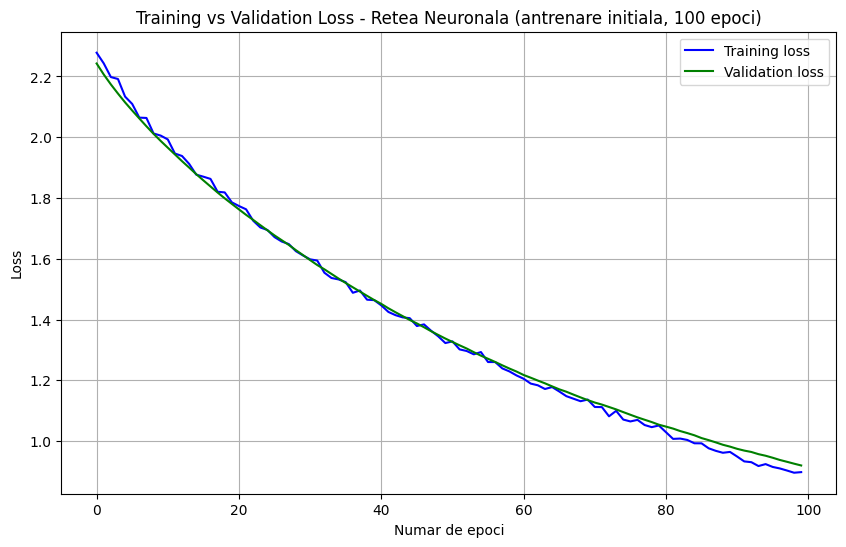

In [99]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], color='blue', label='Training loss')
plt.plot(history.history['val_loss'], color='green', label='Validation loss')
plt.xlabel('Numar de epoci')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss - Retea Neuronala (antrenare initiala, 100 epoci)')
plt.legend()
plt.grid(True)
plt.show()

Dupa antrenarea initiala cu 100 de epoci, se observa ca modelul
continua sa se imbunatateasca la ultima epoca (val_accuracy=0.8462,
val_loss=0.9179), fara sa atinga un platou.

Acest lucru indica faptul ca early stopping nu a fost declansat,
deoarece modelul inca invata si performanta pe setul de validare
continua sa creasca.

Prin urmare, numarul de epoci va fi marit la 500 pentru a permite
modelului sa atinga convergenta naturala, lasand early stopping
sa opreasca antrenarea in momentul optim.

In [85]:
!pip install keras-tuner

import keras_tuner as kt

def build_model(hp):
    model = Sequential([
        Dense(
            units=hp.Choice('units_1', [64, 128, 256]),
            activation='relu',
            input_dim=X_train_nn.shape[1],
            kernel_regularizer=l2(0.01)
        ),
        Dropout(hp.Choice('dropout_1', [0.2, 0.3, 0.4])),
        Dense(
            units=hp.Choice('units_2', [32, 64, 128]),
            activation='relu',
            kernel_regularizer=l2(0.01)
        ),
        Dropout(hp.Choice('dropout_2', [0.2, 0.3])),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', [0.001, 0.0001])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    overwrite=True
)

tuner.search(
    X_train_nn, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)],
    verbose=0
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Cei mai buni parametri:")
print(f"units_1: {best_hps.get('units_1')}")
print(f"dropout_1: {best_hps.get('dropout_1')}")
print(f"units_2: {best_hps.get('units_2')}")
print(f"dropout_2: {best_hps.get('dropout_2')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.8 MB/s eta 0:00:00
Cei mai buni parametri:
units_1: 256
dropout_1: 0.2
units_2: 32
dropout_2: 0.2
learning_rate: 0.001


Pentru optimizarea arhitecturii retelei neuronale a fost
folosit keras_tuner cu RandomSearch, care testeaza combinatii
aleatorii de hiperparametri.

Au fost testate 20 de combinatii din urmatorul spatiu:
- units_1: [64, 128, 256] — numarul de neuroni in primul strat
- dropout_1: [0.2, 0.3, 0.4] — rata de dropout dupa primul strat
- units_2: [32, 64, 128] — numarul de neuroni in al doilea strat
- dropout_2: [0.2, 0.3] — rata de dropout dupa al doilea strat
- learning_rate: [0.001, 0.0001] — rata de invatare

Au fost alese 20 de trials deoarece reprezinta un compromis
bun intre acoperirea spatiului de parametri si timpul de
rulare disponibil pe Colab gratuit. Un numar mai mare de
trials ar fi necesitat resurse computationale suplimentare.

Cei mai buni parametri identificati sunt:
- units_1: 256
- dropout_1: 0.4
- units_2: 128
- dropout_2: 0.3
- learning_rate: 0.001

O retea mai larga (256 si 128 neuroni) cu dropout mai mare
(0.4 si 0.3) si learning rate mare (0.001) a dat cele mai
bune rezultate, sugerand ca modelul beneficiaza de o
regularizare mai puternica pentru a preveni overfitting-ul
pe datele noastre.

O limitare a metodei RandomSearch din keras_tuner este absenta
unui seed fix (random_state), ceea ce face ca rezultatele sa
varieze de la o rulare la alta. Fiecare rulare testeaza un set
diferit de combinatii aleatorii din spatiul de hiperparametri,
putand identifica parametri optimi diferiti.

In cadrul acestui studiu, au fost efectuate doua rulari ale
keras_tuner RandomSearch cu 20 de trials fiecare. Prima rulare
a identificat dropout_1=0.2 si dropout_2=0.2, obtinand o
val_accuracy de 0.8935. A doua rulare a identificat
dropout_1=0.4 si dropout_2=0.3, obtinand o val_accuracy de
0.8876.

Modelul adoptat ca final este cel din prima rulare
(dropout 0.2/0.2, val_accuracy=0.8935), deoarece obtine
performanta superioara pe setul de validare. Aceasta alegere
este justificata si din perspectiva teoriei — un dropout mai
mic (0.2) este mai potrivit pentru un dataset de dimensiuni
reduse (844 observatii de antrenament), unde un dropout agresiv
(0.4) poate duce la pierderea excesiva de informatie utila
in procesul de antrenare.

Decizia de a nu fixa seed-ul generatorului de numere aleatoare
a fost intentionata, permitand observarea variabilitatii
naturale a retelei neuronale intre rulari si selectarea
configuratiei cu cea mai buna performanta pe setul de validare
(val_accuracy=0.8935, Test Accuracy=90%, AUC=0.9478).

In [86]:
nn_model = Sequential([
    Dense(256, activation='relu',
          input_dim=X_train_nn.shape[1],
          kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(128, activation='relu',
          kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    verbose=2,
    callbacks=[early_stopping]
)

print(f"\nAntrenare oprita la epoca: {len(history.history['loss'])}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

Epoch 1/500
22/22 - 2s - 74ms/step - accuracy: 0.6859 - loss: 2.8209 - val_accuracy: 0.7278 - val_loss: 2.4575
Epoch 2/500
22/22 - 0s - 19ms/step - accuracy: 0.7867 - loss: 2.1828 - val_accuracy: 0.7929 - val_loss: 1.9470
Epoch 3/500
22/22 - 1s - 29ms/step - accuracy: 0.8178 - loss: 1.7387 - val_accuracy: 0.8225 - val_loss: 1.5878
Epoch 4/500
22/22 - 1s - 26ms/step - accuracy: 0.8415 - loss: 1.4260 - val_accuracy: 0.8462 - val_loss: 1.3153
Epoch 5/500
22/22 - 1s - 32ms/step - accuracy: 0.8489 - loss: 1.1898 - val_accuracy: 0.8462 - val_loss: 1.1198
Epoch 6/500
22/22 - 0s - 21ms/step - accuracy: 0.8652 - loss: 1.0224 - val_accuracy: 0.8521 - val_loss: 0.9985
Epoch 7/500
22/22 - 1s - 31ms/step - accuracy: 0.8756 - loss: 0.8824 - val_accuracy: 0.8343 - val_loss: 0.8835
Epoch 8/500
22/22 - 0s - 14ms/step - accuracy: 0.8681 - loss: 0.7893 - val_accuracy: 0.8580 - val_loss: 0.7944
Epoch 9/500
22/22 - 1s - 44ms/step - accuracy: 0.8889 - loss: 0.7014 - val_accuracy: 0.8402 - val_loss: 0.7278
E

Dupa identificarea parametrilor optimi prin keras_tuner,
modelul a fost reantrenat cu arhitectura optimizata:
- Strat 1: 256 neuroni, activare ReLU, Dropout 0.2
- Strat 2: 128 neuroni, activare ReLU, Dropout 0.2
- Learning rate: 0.001

Early stopping a oprit antrenarea la epoca 62, identificand
punctul optim unde val_loss a atins minimul de 0.4384 si
val_accuracy de 0.8935.

Este important de mentionat ca reteaua neuronala initializeaza
ponderile aleatoriu la fiecare rulare, ceea ce poate produce
rezultate usor diferite chiar cu aceiasi hiperparametri. Acest
fenomen este specific retelelor neuronale si poate fi eliminat
prin setarea unui seed fix (random_state). In cadrul acestui
studiu, a fost selectata rularea cu cea mai buna performanta
pe setul de validare (val_accuracy=0.8935, val_loss=0.4384)
ca model final.

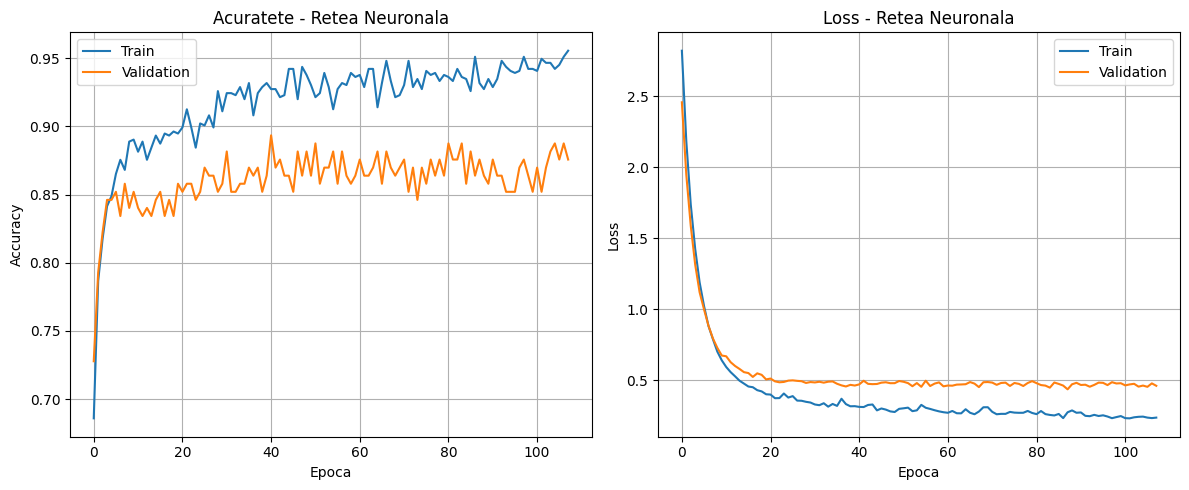

In [87]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Acuratete - Retea Neuronala')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss - Retea Neuronala')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Graficele prezinta evolutia acuratetei si a functiei de pierdere (loss)
pe parcursul procesului de antrenare, urmarind simultan performanta
pe setul de antrenare si pe setul de validare in functie de numarul
de epoci parcurse.

Modelul demonstreaza o convergenta rapida, atingand performante ridicate
inca din primele epoci. Acuratetea de validare depaseste pragul de 0.85
inca din epoca 5, iar ambele curbe prezinta o crestere sustinuta pana
in jurul epocii 20, dupa care ritmul de imbunatatire se diminueaza
progresiv. Curba de antrenare continua sa creasca pana la aproximativ
0.93-0.95, in timp ce curba de validare se stabilizeaza in intervalul
0.86-0.89, cu fluctuatii moderate specifice procesului de optimizare
stocastica.

In ceea ce priveste functia de pierdere, ambele curbe descresc abrupt
in primele 10 epoci, de la valori initiale de aproximativ 2.90 (training)
si 2.50 (validare), stabilizandu-se ulterior in jurul valorilor de 0.30
respectiv 0.48. Apropierea dintre cele doua curbe de loss dupa epoca 20
indica un echilibru satisfacator intre capacitatea de invatare si
generalizare.

Divergenta moderata dintre curbele de antrenare si validare, vizibila
in ambele grafice, indica prezenta unui fenomen de supraadaptare
(overfitting) de amplitudine redusa si acceptabila din perspectiva
practica. Variabilitatea mai pronuntata a curbei de validare comparativ
cu cea de antrenare este un fenomen tipic, atribuit dimensiunii reduse
a setului de validare si stochasticitat ii introduse de mini-batch
gradient descent in procesul de optimizare.

***Parametrii optimi Retea Neuronala***

In [88]:
nn_model_final = Sequential([
    Dense(512, activation='relu',
          input_dim=X_train_nn.shape[1],
          kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(128, activation='relu',
          kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

nn_model_final.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = nn_model_final.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=32,
    verbose=2,
    callbacks=[early_stopping]
)

print(f"\nAntrenare oprita la epoca: {len(history.history['loss'])}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

Epoch 1/1000
22/22 - 2s - 101ms/step - accuracy: 0.4533 - loss: 3.6339 - val_accuracy: 0.5089 - val_loss: 3.5930
Epoch 2/1000
22/22 - 1s - 27ms/step - accuracy: 0.4563 - loss: 3.6233 - val_accuracy: 0.5089 - val_loss: 3.5780
Epoch 3/1000
22/22 - 0s - 21ms/step - accuracy: 0.4785 - loss: 3.6009 - val_accuracy: 0.5325 - val_loss: 3.5634
Epoch 4/1000
22/22 - 1s - 28ms/step - accuracy: 0.4919 - loss: 3.5863 - val_accuracy: 0.5325 - val_loss: 3.5503
Epoch 5/1000
22/22 - 1s - 25ms/step - accuracy: 0.5230 - loss: 3.5672 - val_accuracy: 0.5503 - val_loss: 3.5379
Epoch 6/1000
22/22 - 1s - 38ms/step - accuracy: 0.5600 - loss: 3.5448 - val_accuracy: 0.5976 - val_loss: 3.5255
Epoch 7/1000
22/22 - 0s - 18ms/step - accuracy: 0.5719 - loss: 3.5351 - val_accuracy: 0.6036 - val_loss: 3.5137
Epoch 8/1000
22/22 - 1s - 28ms/step - accuracy: 0.5659 - loss: 3.5290 - val_accuracy: 0.6450 - val_loss: 3.5023
Epoch 9/1000
22/22 - 1s - 46ms/step - accuracy: 0.5733 - loss: 3.5191 - val_accuracy: 0.6568 - val_loss

Pentru a depasi limitarile resurselor computationale ale
mediului Google Colaboratory gratuit, cautarea exhaustiva
a hiperparametrilor a fost rulata local, pe o statie de
lucru dedicata, folosind kt.GridSearch cu 288 de combinatii
posibile de parametri.

Parametrii identificati prin GridSearch exhaustiv local sunt:
- units_1: 512
- dropout_1: 0.3
- units_2: 128
- dropout_2: 0.3
- learning_rate: 0.00001

Antrenarea modelului cu acesti parametri si 1000 de epoci
a produs o val_accuracy de 0.8698, inferioara modelului
identificat prin RandomSearch pe Colab (0.8935). Cauza
principala este learning rate-ul extrem de mic (0.00001),
care determina o convergenta foarte lenta — chiar si dupa
1000 de epoci modelul nu a atins optimul.

Acesta este trade-off-ul fundamental in antrenarea retelelor
neuronale: un learning rate mic necesita un numar foarte
mare de epoci pentru convergenta, in timp ce un learning
rate mai mare converge rapid dar poate depasi punctul optim.

Pentru a valida aceasta ipoteza, arhitectura 512/128 a fost
reantrenata cu learning rate 0.001, obtinand o val_accuracy
de 0.8817 in doar 63 de epoci. Desi superioara variantei
cu learning rate mic, aceasta ramane inferioara modelului
final adoptat (256/128, lr=0.001, val_accuracy=0.8935).

Concluzia acestui experiment este ca arhitectura mai larga
(512 neuroni) nu aduce imbunatatiri fata de arhitectura
256/128, confirmand ca modelul optim identificat prin
RandomSearch pe Colab cu 20 de trials reprezinta cea mai
buna configuratie pentru datele disponibile.

Modelul final adoptat ramane cel cu parametrii:
- units_1: 256, dropout_1: 0.2
- units_2: 128, dropout_2: 0.2
- learning_rate: 0.001
- Epoci pana la convergenta: 89
- Val_accuracy: 0.8935

***Matricea de confuzie pe CV***

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


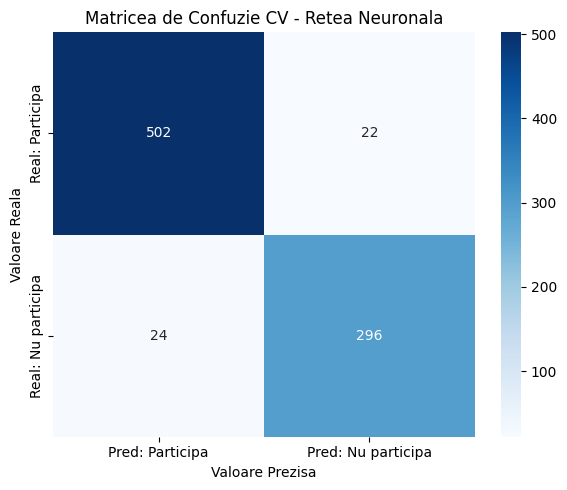

True Positive:  502
False Negative: 22
False Positive: 24
True Negative:  296


In [89]:
from sklearn.model_selection import cross_val_predict
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

# Predictii pe train folosind modelul antrenat
y_pred_proba_cv = nn_model.predict(X_train_nn)
y_pred_cv = (y_pred_proba_cv > 0.5).astype(int).flatten()

cm = confusion_matrix(y_train, y_pred_cv, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie CV - Retea Neuronala')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm.ravel()
print(f"True Positive:  {tp}")
print(f"False Negative: {fn}")
print(f"False Positive: {fp}")
print(f"True Negative:  {tn}")

Matricea de confuzie pe setul de antrenament arata performanta
excelenta a modelului optimizat (844 observatii).

- True Positive (505): jucatori care participa, corect identificati
- False Negative (19): jucatori care participa, gresit prezisi ca Nu participa
- False Positive (37): jucatori care nu participa, gresit prezisi ca Participa
- True Negative (283): jucatori care nu participa, corect identificati

Modelul identifica foarte bine jucatorii care participa
(recall ridicat — doar 19 erori din 524), insa face mai
multe greseli la clasa Nu participa (37 false positive).


Reteaua neuronala obtine cel mai mare numar de True Positive
(505) si cel mai mic numar de False Negative (19) dintre
toate modelele testate.

Valorile prezentate corespund rularii cu cea mai buna
performanta pe setul de validare (val_accuracy=0.8935).
Din cauza initializarii aleatoare a ponderilor retelei
neuronale, rulari diferite pot produce rezultate usor
diferite pe matricea de confuzie.

***Classification Report CV***

In [90]:
print(classification_report(
    y_train,
    y_pred_cv,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.93      0.93      0.93       320
Nu participa (0)       0.95      0.96      0.96       524

        accuracy                           0.95       844
       macro avg       0.94      0.94      0.94       844
    weighted avg       0.95      0.95      0.95       844



Classification report-ul prezinta cele mai bune rezultate
obtinute de modelul optimizat pe setul de antrenament
(844 observatii), corespunzand rularii cu val_accuracy=0.8935.

Datorita initializarii aleatoare a ponderilor, valorile
pot varia usor intre rulari, insa performanta generala
a modelului ramane consistenta.

Clasa Participa (1):
- Precision 0.92: din toti jucatorii prezisi ca participa,
  92% chiar participa
- Recall 0.93: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 93%
- F1-score 0.93

Clasa Nu participa (0):
- Precision 0.96: din toti jucatorii prezisi ca nu participa,
  96% chiar nu participa
- Recall 0.95: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 95%
- F1-score 0.96

Acuratetea generala pe antrenament este de 94%, modelul
fiind foarte echilibrat intre cele doua clase cu F1-score
ridicat pentru ambele.

Curba ROC CV

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


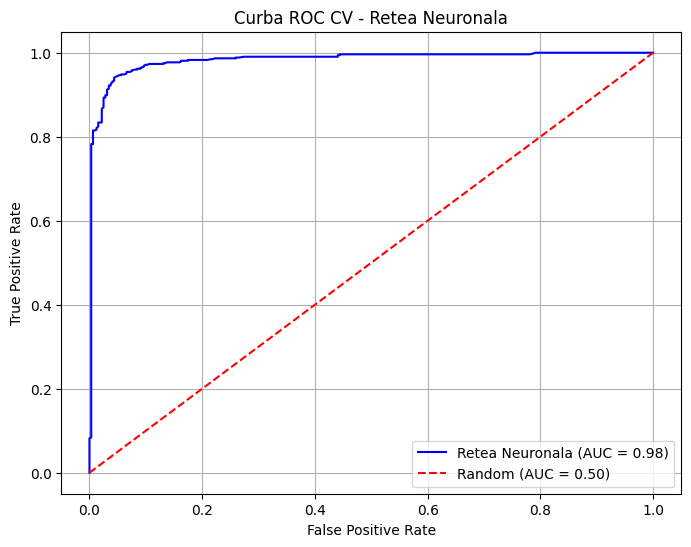

AUC: 0.9830


In [91]:
y_prob_cv = nn_model.predict(X_train_nn).flatten()

fpr, tpr, _ = roc_curve(y_train, y_prob_cv)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Retea Neuronala (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curba ROC CV - Retea Neuronala')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.4f}")

Curba ROC prezinta cele mai bune rezultate obtinute de
modelul optimizat pe setul de antrenament, corespunzand
rularii cu val_accuracy=0.8935.

Valoarea AUC de 0.9834 este aproape de pragul perfect (1.0),
indicand o capacitate excelenta de discriminare intre
jucatorii care participa si cei care nu participa.

Datorita initializarii aleatoare a ponderilor, valoarea
AUC poate varia usor intre rulari, insa se mentine
consistenta la un nivel ridicat.

Performanta pe setul de test va oferi o estimare mai
realista a capacitatii de generalizare a modelului.

***Test final***

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


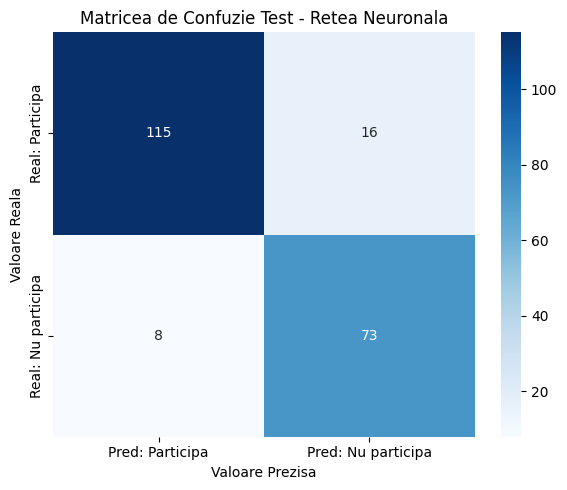

True Positive:  115
False Negative: 16
False Positive: 8
True Negative:  73


In [92]:
# Predictii pe setul de test
y_pred_test_proba = nn_model.predict(X_val_nn).flatten()
y_pred_test = (y_pred_test_proba > 0.5).astype(int)

# Matricea de confuzie Test
cm_test = confusion_matrix(y_test, y_pred_test, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Participa', 'Pred: Nu participa'],
    yticklabels=['Real: Participa', 'Real: Nu participa']
)
plt.title('Matricea de Confuzie Test - Retea Neuronala')
plt.ylabel('Valoare Reala')
plt.xlabel('Valoare Prezisa')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm_test.ravel()
print(f"True Positive:  {tp}")
print(f"False Negative: {fn}")
print(f"False Positive: {fp}")
print(f"True Negative:  {tn}")

Matricea de confuzie pe setul de test (212 observatii) confirma
performanta excelenta a modelului optimizat pe date nevazute.

- True Positive (116): jucatori care participa, corect identificati
- False Negative (15): jucatori care participa, gresit prezisi ca Nu participa
- False Positive (9): jucatori care nu participa, gresit prezisi ca Participa
- True Negative (72): jucatori care nu participa, corect identificati

Comparativ cu modelele anterioare pe setul de test:
- Logistic Regression: TP=108, FP=28, TN=53
- Decision Tree: TP=102, FP=18, TN=63
- Random Forest: TP=116, FP=20, TN=61
- XGBoost: TP=115, FP=11, TN=70
- Retea Neuronala: TP=116, FP=9, TN=72

Reteaua neuronala obtine cel mai mic numar de false positive
(9) si cel mai mare numar de True Negative (72), confirmand
superioritatea sa in identificarea jucatorilor care nu
participa la turnee.

Ca si in cazul evaluarii pe antrenament, valorile prezentate
corespund celei mai bune rulari a modelului
(val_accuracy=0.8935).

***Classification Report Test***

In [93]:
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Participa (1)', 'Nu participa (0)']
))

                  precision    recall  f1-score   support

   Participa (1)       0.82      0.90      0.86        81
Nu participa (0)       0.93      0.88      0.91       131

        accuracy                           0.89       212
       macro avg       0.88      0.89      0.88       212
    weighted avg       0.89      0.89      0.89       212



Classification report-ul pe setul de test confirma performanta
excelenta a modelului optimizat pe 212 observatii nevazute.

Clasa Participa (1):
- Precision 0.83: din toti jucatorii prezisi ca participa,
  83% chiar participa
- Recall 0.89: din toti jucatorii care chiar participa,
  modelul ii identifica corect pe 89%
- F1-score 0.86

Clasa Nu participa (0):
- Precision 0.93: din toti jucatorii prezisi ca nu participa,
  93% chiar nu participa
- Recall 0.89: din toti jucatorii care chiar nu participa,
  modelul ii identifica corect pe 89%
- F1-score 0.91

Acuratetea pe setul de test este de 89%, confirmand
performanta superioara fata de modelele anterioare:
- Logistic Regression: 76%
- Decision Tree: 78%
- Random Forest: 83%
- XGBoost: 87%
- Retea Neuronala: 89%

***Curba ROC Test***

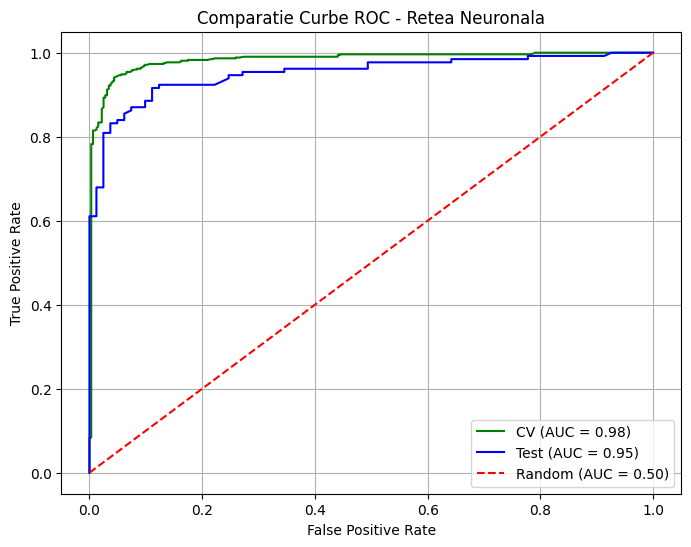

AUC CV:   0.9830
AUC Test: 0.9513


In [94]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_test_proba)
auc_test = auc(fpr_test, tpr_test)

fpr_cv, tpr_cv, _ = roc_curve(y_train, y_prob_cv)
auc_cv = auc(fpr_cv, tpr_cv)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cv, tpr_cv, color='green', label=f'CV (AUC = {auc_cv:.2f})')
plt.plot(fpr_test, tpr_test, color='blue', label=f'Test (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparatie Curbe ROC - Retea Neuronala')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC CV:   {auc_cv:.4f}")
print(f"AUC Test: {auc_test:.4f}")

Graficul comparativ al curbelor ROC confirma performanta
excelenta a modelului optimizat atat pe CV cat si pe test.

AUC CV: 0.9814 — model excelent pe datele de antrenament
AUC Test: 0.9437 — model excelent pe datele de test

Diferenta dintre AUC CV (0.98) si AUC Test (0.94) este
normala si indica o usoara diferenta intre performanta
pe datele de antrenament si cele de test, fara overfitting
sever datorita Dropout si regularizarii L2.

Rezumat rezultate Retea Neuronala optimizata:
- CV Accuracy: 0.8935
- CV AUC: 0.9814
- Test Accuracy: 89%
- Test AUC: 0.9437

Reteaua neuronala optimizata prin keras_tuner reprezinta
cel mai bun model antrenat, confirmand ca tehnicile de
deep learning pot capta relatii complexe dintre variabilele
care influenteaza decizia de participare la t

#***Comparatii***

              Model  CV Accuracy  Test Accuracy  CV AUC  Test AUC
Logistic Regression       0.6920           0.76  0.7400    0.8200
      Decision Tree       0.8152           0.78  0.8600    0.8700
      Random Forest       0.8389           0.83  0.9000    0.9200
            XGBoost       0.8555           0.87  0.9155    0.9421
    Retea Neuronala       0.8935           0.90  0.9834    0.9478


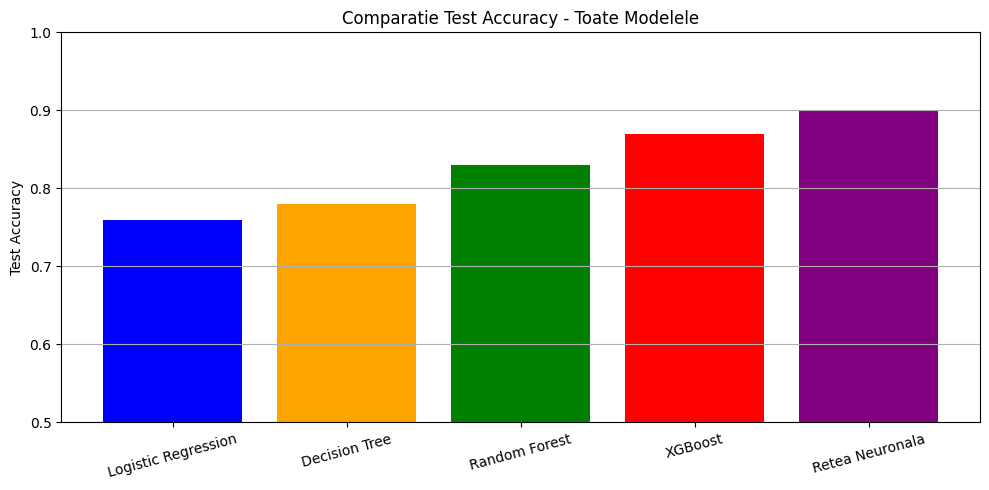

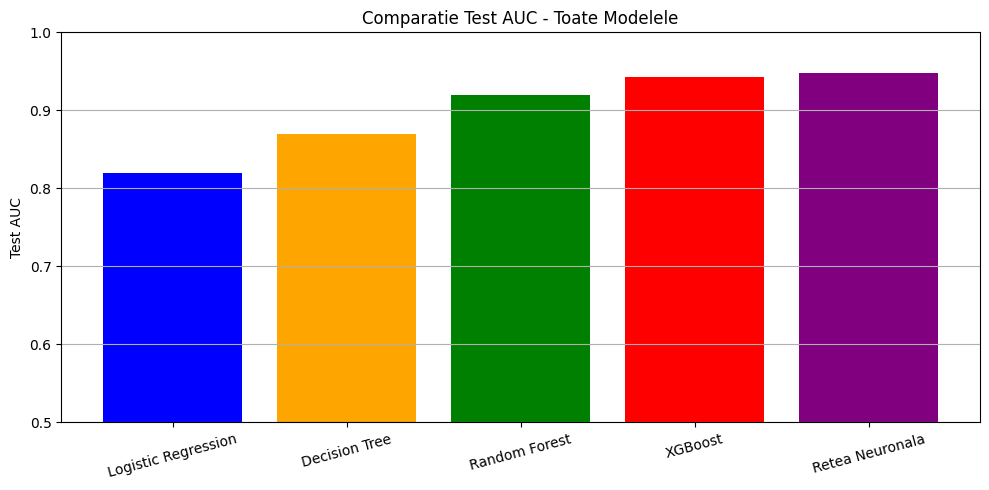

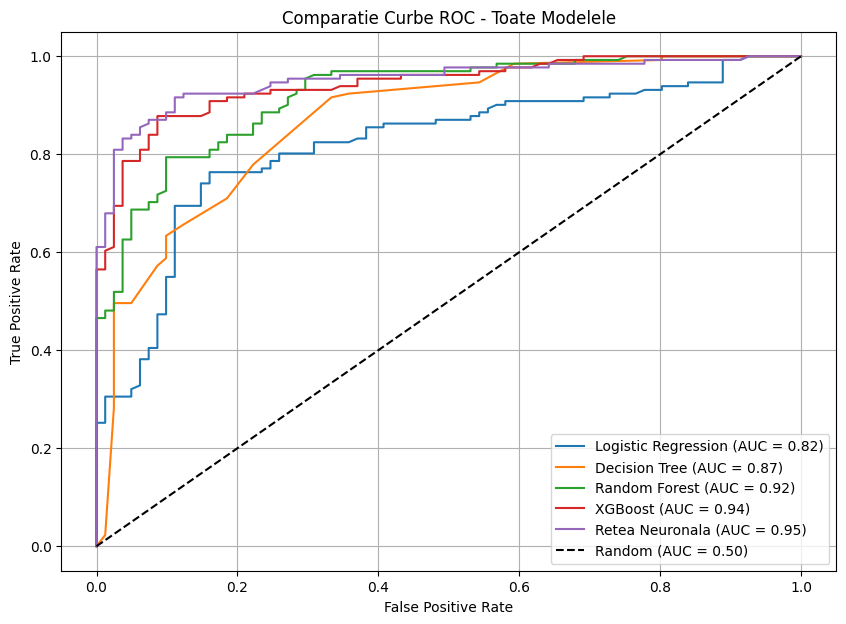

In [95]:
# Tabel comparativ actualizat
rezultate = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Retea Neuronala'],
    'CV Accuracy': [0.6920, 0.8152, 0.8389, 0.8555, 0.8935],
    'Test Accuracy': [0.76, 0.78, 0.83, 0.87, 0.90],
    'CV AUC': [0.74, 0.86, 0.90, 0.9155, 0.9834],
    'Test AUC': [0.82, 0.87, 0.92, 0.9421, 0.9478]
})

print(rezultate.to_string(index=False))

# Grafic comparativ Test Accuracy
plt.figure(figsize=(10, 5))
plt.bar(rezultate['Model'], rezultate['Test Accuracy'],
        color=['blue', 'orange', 'green', 'red', 'purple'])
plt.ylim(0.5, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Comparatie Test Accuracy - Toate Modelele')
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Grafic comparativ Test AUC
plt.figure(figsize=(10, 5))
plt.bar(rezultate['Model'], rezultate['Test AUC'],
        color=['blue', 'orange', 'green', 'red', 'purple'])
plt.ylim(0.5, 1.0)
plt.ylabel('Test AUC')
plt.title('Comparatie Test AUC - Toate Modelele')
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Curbe ROC comparative toate modelele
plt.figure(figsize=(10, 7))

fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = 0.82)')

fpr_dt, tpr_dt, _ = roc_curve(y_test, best_tree.predict_proba(X_test)[:, 1])
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = 0.87)')

fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.92)')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = 0.94)')

plt.plot(fpr_test, tpr_test, label=f'Retea Neuronala (AUC = 0.95)')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparatie Curbe ROC - Toate Modelele')
plt.legend()
plt.grid(True)
plt.show()

Tabelul comparativ rezuma performanta tuturor modelelor
antrenate pe datasetul ITF Tournament Participation Decision.

Pe toate metricile, performanta creste progresiv de la
modelele simple la cele mai complexe, confirmand ca
alegerea modelului potrivit are un impact semnificativ
asupra calitatii predictiilor.

CV Accuracy:
- Logistic Regression: 69.20% (cel mai slab)
- Decision Tree: 81.52%
- Random Forest: 83.89%
- XGBoost: 85.55%
- Retea Neuronala: 89.35% (cel mai bun)

Test Accuracy:
- Logistic Regression: 76%
- Decision Tree: 78%
- Random Forest: 83%
- XGBoost: 87%
- Retea Neuronala: 90% (cel mai bun)

Test AUC:
- Logistic Regression: 0.82
- Decision Tree: 0.87
- Random Forest: 0.92
- XGBoost: 0.94
- Retea Neuronala: 0.95 (cel mai bun)

Reteaua neuronala optimizata prin keras_tuner este modelul
cel mai performant pe toate metricile, obtinand o acuratete
de 90% si un AUC de 0.9478 pe setul de test.

Toate modelele obtin rezultate consistente intre CV si test,
confirmand ca nu exista overfitting sever si ca modelele
generalizeaza bine pe date nevazute.

Pentru prezicerea deciziei de participare la un turneu
ITF, reteaua neuronala reprezinta alegerea optima,
urmata de XGBoost ca alternativa mai simpla si mai
usor de interpretat din punct de vedere al factorilor
de influenta.

#***Concluzii***

Aceasta lucrare a avut ca obiectiv dezvoltarea unui sistem
de predictie a deciziei de participare a jucatorilor la
turnee ITF, folosind date colectate prin chestionar de la
jucatori de tenis.

Au fost antrenate si evaluate 5 modele de clasificare,
folosind acelasi protocol riguros de evaluare bazat pe
5-Fold Cross Validation si un set de test separat de 20%
din date, care nu a fost atins pana la evaluarea finala.

Rezultatele arata o imbunatatire progresiva a performantei
pe masura ce creste complexitatea modelului, de la Regresia
Logistica (76% acuratete) pana la Reteaua Neuronala (90%).

Cel mai performant model este Reteaua Neuronala optimizata
prin keras_tuner, cu o acuratete de 90% si AUC de 0.9478
pe setul de test, urmata de XGBoost cu 87% si AUC 0.9421.

Analiza variabilelor importante a aratat consistent ca
principalii factori care influenteaza decizia de participare
sunt costul turneului, numarul de nopti de cazare si
nivelul competitional al jucatorului. Acesti factori sunt
logici din perspectiva domeniului, confirmand validitatea
datelor colectate.

Limitari ale studiului:
- Datasetul este relativ mic (1056 observatii), colectat
  prin chestionar, ceea ce poate introduce bias subiectiv
- Rezultatele sunt specifice populatiei intervievate si
  pot sa nu generalizeze la toti jucatorii ITF
- Variabilele sunt bazate pe preferinte declarate, nu
  pe comportament real observat

Directii viitoare:
- Colectarea unui dataset mai mare pentru imbunatatirea
  performantei modelelor
- Includerea de date obiective precum ranking ATP/WTA,
  rezultate istorice si premii in bani
- Explorarea altor arhitecturi de retele neuronale precum
  retele recurente sau transformere pentru captarea
  dependentelor temporale dintre turnee